<center><img src='https://netacad.centralesupelec.fr/img/cs.jpg' width=200></center>

<h6><center>Introduction au Machine Learning — Projet</center></h6>

<h1>
<hr style=" border:none; height:3px;">
<center>Prédiction de la qualité de soudures<br>Notebook 1 : analyse exploratoire des données</center>
<hr style=" border:none; height:3px;">
</h1>

## Objectif et démarche

On veut prédire la **qualité de soudures sur des aciers** à partir de leur composition et de leurs conditions de soudage. Avant de choisir un modèle, il faut comprendre la base : ce que contient chaque colonne, ce qui est fiable, ce qui manque, et comment les lignes sont reliées entre elles.

Ce notebook ne présente pas seulement des résultats : il suit le **raisonnement** qui mène à chaque choix de pré-traitement. Chaque étape suit le même schéma :

1. **Constat** : ce que l'on observe dans les données (une sortie de code, une figure) ;
2. **Question** : ce que ce constat nous oblige à décider ;
3. **Vérification** : un calcul pour confirmer ou infirmer notre interprétation ;
4. **Décision** : le choix retenu, *pourquoi*, et les alternatives écartées.

Les décisions sont enregistrées au fur et à mesure avec la fonction `decide()` et récapitulées dans un **journal des décisions** en fin de notebook (réutilisable pour la section « pré-traitement » du rapport).

Certaines décisions sont des **hypothèses** qu'on ne peut pas prouver avec les seules données ; on le signale explicitement. D'autres ont été prises **après coup**, quand une étape ultérieure a révélé un problème (c'est normal en analyse exploratoire) : on l'indique aussi.

**Plan**
1. Premier contact avec le fichier
2. Organiser les variables : quel rôle joue chaque colonne ?
3. Diagnostic et nettoyage des valeurs
4. Valeurs manquantes
5. Structure de la base : sources et lignes répétées
6. Variables d'entrée
7. Variables cibles : qu'est-ce qu'une « bonne » soudure ?
8. Liens entre entrées et cibles
9. Analyse en composantes principales
10. Clustering
11. Export
12. Journal des décisions et questions ouvertes

# 0. Librairies, style et journal des décisions

In [1]:
import sys
assert sys.version_info >= (3, 8)

import os
import re
import tarfile
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.precision", 3)

# Style : une palette catégorielle fixe (3 couleurs max. par figure) et une rampe séquentielle bleue
sns.set_theme(style="whitegrid", context="notebook")
C_BLUE, C_ORANGE, C_AQUA, C_GREY = "#2a78d6", "#eb6834", "#1baf7a", "#b5b4ae"
PAL3 = [C_BLUE, C_ORANGE, C_AQUA]
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.spines.top": False,
                     "axes.spines.right": False, "legend.frameon": False})

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name + ".png"), dpi=200, bbox_inches="tight")

# Journal des décisions
DECISIONS = []
def decide(etape, decision, pourquoi, alternatives="—"):
    """Enregistre une décision de pré-traitement et l'affiche."""
    DECISIONS.append({"étape": etape, "décision": decision, "pourquoi": pourquoi,
                      "alternatives écartées": alternatives})
    print(f"DÉCISION [{etape}] {decision}\n   pourquoi : {pourquoi}\n   alternatives écartées : {alternatives}")

print("pandas", pd.__version__, "| scikit-learn", sklearn.__version__)

pandas 3.0.2 | scikit-learn 1.8.0


# 1. Premier contact avec le fichier

## 1.1 Ce que dit la documentation

L'archive `welddb.tar` (à placer à côté du notebook) contient `welddb.data` (les données) et `welddb.info` (la description). On commence par **lire la documentation**, car elle conditionne tout le reste. Ce qu'on en retient :

+ 44 colonnes, sans en-tête, séparées par des espaces ; une ligne par soudure ;
+ les colonnes 1–12 (C à W) sont en **% massique**, les colonnes 13–21 (O à Sb) en **ppm massique** : deux unités différentes pour des grandeurs de même nature ;
+ **« N » signifie « non rapporté dans la publication » et n'indique pas une valeur nulle** ;
+ les données ont été compilées depuis la littérature par Cool & Bhadeshia (Cambridge, 1996–1997) pour entraîner des réseaux de neurones.

On affiche la documentation pour garder la liste des colonnes sous les yeux :

In [2]:
with tarfile.open("welddb.tar") as tar:
    info = tar.extractfile("welddb.info").read().decode("latin-1")
print(info[:3500])

MAP DATA LIBRARY

Database MAP_DATA_WELD

Provenance of Source Code

Tracey Cool* and H. K. D. H. Bhadeshia, Phase Transformations Group, Department of Materials Science and Metallurgy, University of Cambridge, Cambridge, U.K.

*TC is now in the Materials Engineering Department, Parsons Power Generation Systems Ltd, Heaton Works, Shields Road, Newcastle Upon Tyne, NE6 2YL

Purpose

Provides chemical composition and mechanical property data for a collection of all weld metal deposits.


Description

The tar file contains data for the chemical composition of the steels studied, and their room temperature mechanical properties. These data have been collated from available literature. The presence of an ``N'' indicates that the value was not reported in the publication. This is NOT meant to be an indication that the value is zero. Although many columns are presented here, those which only have a small amaount of data have been removed for the analysis described in [1 and 2]. This enabled m

## 1.2 Une première lecture naïve

**Constat attendu** : si toutes les colonnes numériques ne contenaient que des nombres et des « N », `pandas` devrait les lire comme des `float`. Essayons sans rien préciser :

In [3]:
COLS = ["C", "Si", "Mn", "S", "P", "Ni", "Cr", "Mo", "V", "Cu", "Co", "W",
        "O", "Ti", "N", "Al", "B", "Nb", "Sn", "As", "Sb",
        "Current", "Voltage", "AC_DC", "Polarity", "HeatInput", "Interpass", "WeldType",
        "PWHT_T", "PWHT_t",
        "YS", "UTS", "Elong", "RoA", "CharpyT", "CharpyJ", "Hardness", "FATT50",
        "PrimFerrite", "FerrSecPh", "AcicFerr", "Martensite", "FerrCarb",
        "WeldID"]

with tarfile.open("welddb.tar") as tar:
    naive = pd.read_csv(tar.extractfile("welddb.data"), sep=r"\s+", header=None, names=COLS)

is_num = naive.dtypes.apply(pd.api.types.is_numeric_dtype)
print("Dimensions :", naive.shape)
print("Colonnes lues comme numériques :", list(naive.columns[is_num]))
print("Colonnes lues comme texte      :", len(naive.columns[~is_num]), "sur", len(COLS))

Dimensions : (1652, 44)
Colonnes lues comme numériques : ['C', 'Si', 'Mn', 'HeatInput']
Colonnes lues comme texte      : 40 sur 44


**Constat** : seules 4 colonnes sont reconnues comme numériques, et ce sont exactement des colonnes **toujours renseignées** (C, Si, Mn, énergie de soudage). Les « N » suffisent donc à faire basculer une colonne en texte, mais ils n'expliquent peut-être pas tout.

**Question** : comment lire le fichier sans perdre d'information ?

**Décision** : lire *tout* comme du texte, déclarer « N » comme valeur manquante, puis inspecter ce qui reste de non numérique (section 3). Convertir directement avec `pd.to_numeric(errors="coerce")` transformerait silencieusement tout format inattendu en `NaN` : on perdrait de l'information sans le savoir.

In [4]:
def load_raw(path_tar="welddb.tar"):
    with tarfile.open(path_tar) as tar:
        return pd.read_csv(tar.extractfile("welddb.data"), sep=r"\s+", header=None, names=COLS,
                           na_values="N", keep_default_na=False, dtype=str)

raw = load_raw()
raw.head()

,C,Si,Mn,S,P,Ni,Cr,Mo,V,Cu,Co,W,O,Ti,N,Al,B,Nb,Sn,As,Sb,Current,Voltage,AC_DC,Polarity,HeatInput,Interpass,WeldType,PWHT_T,PWHT_t,YS,UTS,Elong,RoA,CharpyT,CharpyJ,Hardness,FATT50,PrimFerrite,FerrSecPh,AcicFerr,Martensite,FerrCarb,WeldID
0,0.037,0.30,0.65,0.008,0.012,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170,21,DC,+,1,200,MMA,250,14,392,466,31.9,80.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aaw
1,0.037,0.30,0.65,0.008,0.012,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170,21,DC,+,1,200,MMA,0,0,NaN,NaN,NaN,NaN,-28,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aawch
2,0.037,0.30,0.65,0.008,0.012,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170,21,DC,+,1,200,MMA,580,2,370,456,35.2,80.6,-38,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aht
3,0.037,0.31,1.03,0.007,0.014,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170,21,DC,+,1,200,MMA,250,14,413,498,31.2,80.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Baw
4,0.037,0.31,1.03,0.007,0.014,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170,21,DC,+,1,200,MMA,0,0,NaN,NaN,NaN,NaN,-48,100,NaN,NaN,32,28,40,0,0,Evans-Ni/CMn-1990/1991-0Bawch


**Vérification** du point « N ≠ 0 » de la documentation : si les auteurs distinguent vraiment « non mesuré » et « nul », on doit trouver des zéros explicites dans les colonnes d'éléments d'alliage.

In [5]:
for c in ["Ni", "Cr", "Mo", "Cu"]:
    print(f"{c:3s} : {(raw[c] == '0').sum() + (raw[c] == '0.00').sum():4d} zéros écrits explicitement | "
          f"{raw[c].isna().sum():4d} 'N' (non rapporté)")
decide("1.2", "Lecture en texte ; « N » -> NaN (et non 0)",
       "la documentation le précise et le fichier contient aussi des zéros explicites : les deux notions sont distinctes",
       "remplacer N par 0 (inventerait des teneurs nulles) ; conversion directe to_numeric (perte silencieuse)")

Ni  :  222 zéros écrits explicitement |  955 'N' (non rapporté)
Cr  :  214 zéros écrits explicitement |  868 'N' (non rapporté)
Mo  :  203 zéros écrits explicitement |  859 'N' (non rapporté)
Cu  :  194 zéros écrits explicitement | 1074 'N' (non rapporté)
DÉCISION [1.2] Lecture en texte ; « N » -> NaN (et non 0)
   pourquoi : la documentation le précise et le fichier contient aussi des zéros explicites : les deux notions sont distinctes
   alternatives écartées : remplacer N par 0 (inventerait des teneurs nulles) ; conversion directe to_numeric (perte silencieuse)


# 2. Organiser les variables : quel rôle joue chaque colonne ?

On a 43 variables (hors identifiant). Avant de les analyser, il faut décider **lesquelles peuvent servir d'entrées** d'un modèle et **lesquelles sont à prédire**. Le critère n'est pas statistique mais lié à l'usage :

> Le modèle doit aider à choisir une soudure **avant de la réaliser**. Une variable n'est donc une entrée légitime que si elle est **connue (ou choisie) avant le soudage**.

En appliquant ce critère colonne par colonne :

| Famille | Colonnes | Connue avant soudage ? | Rôle |
|---|---|---|---|
| Composition (%m) | C … W | oui : fixée par le choix de l'électrode / du fil / du flux | **entrée** |
| Composition (ppm) | O … Sb | oui (mêmes raisons), mais mesurée en ppm | **entrée** |
| Procédé | courant, tension, AC/DC, polarité, énergie, T entre passes, type | oui : réglages de l'opérateur | **entrée** |
| Traitement post-soudage | température, durée | oui : décidé à l'avance | **entrée** |
| Propriétés mécaniques | YS, UTS, Elong, RoA, Charpy, dureté, FATT | non : mesurées après | **cibles** |
| Température d'essai Charpy | CharpyT | choisie par l'expérimentateur, ce n'est pas une propriété de la soudure | **condition de mesure** (voir 7.2) |
| Microstructure | % de ferrite, martensite… | non : résultat du soudage | **ni l'un ni l'autre** |

Deux choix méritent justification :

+ **Pourquoi séparer %m et ppm ?** Ce sont les mêmes grandeurs physiques (des teneurs) mais pas les mêmes unités. Les garder séparées permet de vérifier la cohérence des unités (section 3.5). On ne convertit pas tout en %m : cela ne changerait rien pour les modèles après standardisation, et les ordres de grandeur en ppm sont plus lisibles.
+ **Pourquoi exclure la microstructure des entrées ?** Elle est une *conséquence* de la composition et du procédé, et une *cause* des propriétés mécaniques. L'utiliser comme entrée reviendrait à fournir au modèle une partie de la réponse, et elle n'est pas connue au moment de choisir la soudure (en plus d'être très peu renseignée, voir section 4).

In [6]:
CHEM_PCT = ["C", "Si", "Mn", "S", "P", "Ni", "Cr", "Mo", "V", "Cu", "Co", "W"]
CHEM_PPM = ["O", "Ti", "N", "Al", "B", "Nb", "Sn", "As", "Sb"]
PROCESS  = ["Current", "Voltage", "AC_DC", "Polarity", "HeatInput", "Interpass", "WeldType"]
PWHT     = ["PWHT_T", "PWHT_t"]
TARGETS  = ["YS", "UTS", "Elong", "RoA", "CharpyJ"]
TEST     = ["CharpyT"]
OTHER_OUT = ["Hardness", "FATT50"]
MICRO    = ["PrimFerrite", "FerrSecPh", "AcicFerr", "Martensite", "FerrCarb"]
ALL_VARS = CHEM_PCT + CHEM_PPM + PROCESS + PWHT + TARGETS + TEST + OTHER_OUT + MICRO
NUM_COLS = [c for c in ALL_VARS if c not in ("AC_DC", "Polarity", "WeldType")]

UNITS = {**{c: "%m" for c in CHEM_PCT}, **{c: "ppm" for c in CHEM_PPM},
         "Current": "A", "Voltage": "V", "HeatInput": "kJ/mm", "Interpass": "°C",
         "PWHT_T": "°C", "PWHT_t": "h", "YS": "MPa", "UTS": "MPa", "Elong": "%", "RoA": "%",
         "CharpyT": "°C", "CharpyJ": "J", "Hardness": "kg/mm²", "FATT50": "°C", **{c: "%" for c in MICRO}}
LABELS = {"YS": "Limite d'élasticité", "UTS": "Résistance à la traction", "Elong": "Allongement",
          "RoA": "Striction", "CharpyJ": "Énergie Charpy", "CharpyT": "Température d'essai Charpy",
          "HeatInput": "Énergie de soudage", "Interpass": "T entre passes",
          "PWHT_T": "T de traitement post-soudage", "PWHT_t": "Durée de traitement"}
def lab(c):
    return f"{LABELS.get(c, c)} ({UNITS[c]})" if c in UNITS else LABELS.get(c, c)

decide("2", "Entrées = composition + procédé + traitement post-soudage ; cibles = propriétés mécaniques ; "
            "CharpyT = condition d'essai ; microstructure exclue",
       "seules les variables connues avant soudage peuvent servir à prédire / recommander",
       "utiliser la microstructure en entrée (fuite d'information causale + inconnue a priori)")

DÉCISION [2] Entrées = composition + procédé + traitement post-soudage ; cibles = propriétés mécaniques ; CharpyT = condition d'essai ; microstructure exclue
   pourquoi : seules les variables connues avant soudage peuvent servir à prédire / recommander
   alternatives écartées : utiliser la microstructure en entrée (fuite d'information causale + inconnue a priori)


# 3. Diagnostic et nettoyage des valeurs

## 3.1 Inventaire des valeurs non numériques

**Constat** (section 1.2) : même après avoir traité « N », des colonnes restent en texte. Listons exactement quelles valeurs posent problème, colonne par colonne :

In [7]:
rows = []
for c in NUM_COLS:
    s = raw[c].dropna()
    bad = s[pd.to_numeric(s, errors="coerce").isna()]
    if len(bad):
        rows.append((c, len(bad), bad.nunique(), ", ".join(bad.value_counts().index[:5])))
pd.DataFrame(rows, columns=["colonne", "nb valeurs non numériques", "nb distinctes", "exemples"])

,colonne,nb valeurs non numériques,nb distinctes,exemples
0,S,7,1,<0.002
1,Mo,2,1,<0.01
2,V,308,4,"<0.0005, <0.01, <5, <0.005"
3,Cu,14,1,<0.01
4,Co,21,1,<0.01
5,W,12,1,<0.1
6,Ti,70,4,"<100, <0.01, <5, <10"
7,N,59,8,"66totndres, 67tot33res, 61tot34res, 54tot24res..."
8,Al,403,4,"<5, <100, <0.01, <50"
9,B,419,2,"<5, <10"


On repère **quatre formats** différents. On ne les traite pas tous pareil, car ils n'ont pas le même sens :

| Format | Exemple | Sens probable |
|---|---|---|
| `<x` | `<5`, `<0.0005` | valeur sous la limite de détection de l'analyse chimique |
| `…tot…res` | `66tot33res` | azote total (66 ppm) et azote « résiduel » libre (33 ppm) |
| `…Hv…` | `224Hv10` | dureté Vickers, avec la charge d'essai |
| `a-b` | `150-200` | intervalle de température entre passes |

## 3.2 Les valeurs censurées `<x`

**Question** : quelle valeur numérique donner à « moins de $x$ » ? On sait seulement que la vraie teneur est dans $[0, x]$.

Avant de choisir, regardons **quelle proportion** de chaque colonne est concernée : si c'est marginal, le choix importe peu ; si c'est massif, il est déterminant.

In [8]:
cens = {c: raw[c].dropna().str.startswith("<").sum() for c in NUM_COLS}
n_ok = {c: raw[c].notna().sum() for c in NUM_COLS}
tab = pd.DataFrame({"nb censurées": cens, "nb renseignées": n_ok})
tab["% des valeurs renseignées"] = (100 * tab["nb censurées"] / tab["nb renseignées"]).round(1)
tab[tab["nb censurées"] > 0].sort_values("% des valeurs renseignées", ascending=False)

,nb censurées,nb renseignées,% des valeurs renseignées
B,419,504,83.1
Al,403,905,44.5
Nb,299,752,39.8
V,308,928,33.2
Co,21,129,16.3
W,12,75,16.0
Ti,70,935,7.5
As,8,234,3.4
Cu,14,578,2.4
Sb,6,260,2.3


**Constat** : pour le bore (B), plus de 80 % des valeurs renseignées sont `<5` ou `<10` ; pour Al, Nb et V, entre 30 et 45 %. Le choix est donc loin d'être anodin pour ces éléments.

Options possibles :

| Option | Avantage | Inconvénient |
|---|---|---|
| supprimer les lignes | simple | on perdrait des centaines de lignes, et surtout les soudures *sans* ajout de B/Al/Nb : biais |
| remplacer par 0 | « pas d'ajout » | sous-estime systématiquement |
| remplacer par $x$ | prudent | surestime systématiquement |
| remplacer par $x/2$ | milieu de l'intervalle $[0, x]$ si la vraie valeur y est uniformément répartie | reste une approximation |
| $x/2$ + **indicateur** `_cens` | garde l'information « non détecté » que le modèle peut utiliser | ajoute des colonnes |

**Décision** : $x/2$ **et** un indicateur binaire. Pour B, cela signifie que l'information est essentiellement binaire (bore ajouté / non détecté) : c'est ce que l'indicateur capture.

In [9]:
def first_number(v):
    """Premier nombre (éventuellement négatif) d'une chaîne."""
    m = re.search(r"-?\d+\.?\d*", str(v))
    return float(m.group()) if m else np.nan

def parse_value(v):
    """Cellule brute -> (valeur numérique, censurée ?)."""
    if pd.isna(v):
        return np.nan, False
    v = str(v).strip()
    m = re.fullmatch(r"<\s*(\d+\.?\d*)", v)                  # '<x'  -> x/2
    if m:
        return float(m.group(1)) / 2, True
    m = re.fullmatch(r"(-?\d+\.?\d*)\s*-\s*(\d+\.?\d*)", v)  # 'a-b' -> milieu
    if m:
        return (float(m.group(1)) + float(m.group(2))) / 2, False
    return first_number(v), False                            # nombre, '66tot33res', '224Hv10'

decide("3.2", "Valeurs '<x' -> x/2 + indicateur binaire <colonne>_cens",
       "jusqu'à 83 % des valeurs de B sont censurées : il faut une valeur plausible ET garder l'information 'non détecté'",
       "suppression des lignes (biais), 0 ou x (biais systématique)")

DÉCISION [3.2] Valeurs '<x' -> x/2 + indicateur binaire <colonne>_cens
   pourquoi : jusqu'à 83 % des valeurs de B sont censurées : il faut une valeur plausible ET garder l'information 'non détecté'
   alternatives écartées : suppression des lignes (biais), 0 ou x (biais systématique)


## 3.3 Azote `tot/res`, dureté `Hv`, intervalles

On regarde d'où viennent ces formats avant de décider :

In [10]:
m_n = raw["N"].str.contains("tot", na=False)
print("Azote 'tot/res' :", m_n.sum(), "lignes, sources :", raw.loc[m_n, "WeldID"].str.split("-").str[0].unique())
print("Exemples :", raw.loc[m_n, "N"].unique()[:6])
m_i = raw["Interpass"].str.contains("-", na=False)
print("Intervalle T entre passes :", m_i.sum(), "lignes, valeurs :", raw.loc[m_i, "Interpass"].unique())

Azote 'tot/res' : 59 lignes, sources : ['Evans']
Exemples : <StringArray>
['67tot33res', '66totndres', '61tot34res', '54totndres', '54tot24res', '52tot18res']
Length: 6, dtype: str
Intervalle T entre passes : 38 lignes, valeurs : <StringArray>
['150-200']
Length: 1, dtype: str


+ **Azote** : toutes les autres lignes donnent une seule valeur, qui est la teneur totale mesurée par analyse chimique. Pour rester homogène on garde le **total** (le premier nombre). La part « résiduelle » est une information plus fine, disponible pour trop peu de lignes pour être exploitée.
+ **T entre passes `150-200`** : l'auteur donne une plage de régulation ; on prend le **milieu (175 °C)**. L'erreur maximale est de 25 °C, faible devant l'étendue de la variable (20–300 °C).
+ **Dureté `224Hv10`** : on garde le nombre. La charge (10 ou 30 kgf) change peu la valeur de dureté Vickers ; de toute façon la colonne sera peu utilisée (> 90 % de manquants).

On applique maintenant ce parsing à toutes les colonnes numériques :

In [11]:
df = pd.DataFrame(index=raw.index)
for c in NUM_COLS:
    parsed = raw[c].map(parse_value)
    df[c] = parsed.str[0].astype(float)
    if parsed.str[1].any():
        df[c + "_cens"] = parsed.str[1].astype(int)
for c in ["AC_DC", "Polarity", "WeldType", "WeldID"]:
    df[c] = raw[c]

print("Colonnes numériques converties :", len(NUM_COLS), "| indicateurs de censure créés :",
      [c for c in df.columns if c.endswith("_cens")])
decide("3.3", "N 'tot/res' -> total ; 'a-b' -> milieu ; 'xxxHv10' -> nombre",
       "homogénéité avec les autres lignes ; erreur introduite négligeable devant l'étendue des variables")

Colonnes numériques converties : 40 | indicateurs de censure créés : ['S_cens', 'Mo_cens', 'V_cens', 'Cu_cens', 'Co_cens', 'W_cens', 'Ti_cens', 'Al_cens', 'B_cens', 'Nb_cens', 'Sn_cens', 'As_cens', 'Sb_cens', 'PrimFerrite_cens']
DÉCISION [3.3] N 'tot/res' -> total ; 'a-b' -> milieu ; 'xxxHv10' -> nombre
   pourquoi : homogénéité avec les autres lignes ; erreur introduite négligeable devant l'étendue des variables
   alternatives écartées : —


## 3.4 Les unités sont-elles cohérentes ?

**Question** : la documentation annonce des ppm pour O…Sb. Est-ce vrai pour toutes les lignes ? Une erreur d'unité (%m au lieu de ppm) multiplie ou divise une valeur par $10^4$ : sur une **échelle logarithmique**, elle doit apparaître comme un second groupe de valeurs très éloigné du premier.

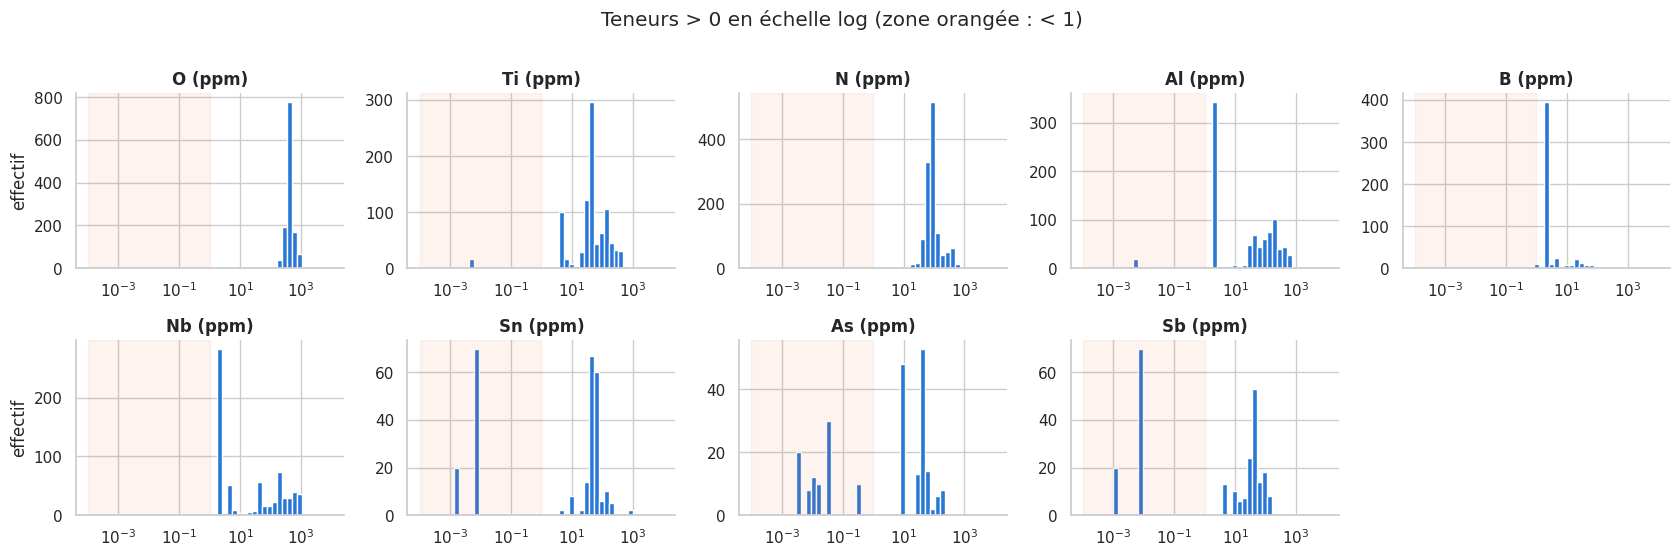

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(17, 5.5))
axes.ravel()[-1].axis("off")
bins = np.logspace(-4, 4, 50)
for ax, c in zip(axes.ravel(), CHEM_PPM):
    s = df[c][df[c] > 0]
    ax.hist(s, bins=bins, color=C_BLUE)
    ax.set_xscale("log"); ax.set_title(f"{c} ({UNITS[c]})")
    ax.axvspan(1e-4, 1, color=C_ORANGE, alpha=0.08)
for ax in axes[:, 0]: ax.set_ylabel("effectif")
plt.suptitle("Teneurs > 0 en échelle log (zone orangée : < 1)", y=1.01)
plt.tight_layout(); savefig("unites_avant"); plt.show()

**Constat** : pour Ti, Al, Sn, As, Sb, un petit groupe de valeurs se situe entre $10^{-3}$ et $10^{-1}$ ppm, à 3–4 ordres de grandeur du groupe principal (10–1000 ppm).

**Deux interprétations possibles** : (a) des teneurs réellement infimes, ou (b) des valeurs saisies en %m par erreur. On les départage par trois vérifications :

1. **Plausibilité physique** : des teneurs de $10^{-3}$ ppm sont bien en dessous des limites de détection des analyses d'acier (de l'ordre du ppm). L'hypothèse (a) est donc peu crédible.
2. **Coïncidence des seuils** : la colonne Ti contient à la fois `<100` et `<0.01`. Or $0{,}01\ \%\text{m} = 100$ ppm : c'est la même limite de détection, exprimée dans deux unités.
3. **Concentration par publication** : une erreur de recopie se produit publication par publication. Si (b) est vraie, les petites valeurs doivent venir de **quelques sources seulement**.

In [13]:
src_raw = raw["WeldID"].str.split("-").str[0]
small = pd.DataFrame({c: (df[c] > 0) & (df[c] < 1) for c in CHEM_PPM})
print("Nombre de valeurs dans ]0, 1[ par colonne :", small.sum()[small.sum() > 0].to_dict())
src_raw[small.any(axis=1)].value_counts().rename_axis("source").to_frame("nb lignes concernées")

Nombre de valeurs dans ]0, 1[ par colonne : {'Ti': 17, 'Al': 26, 'Sn': 90, 'As': 90, 'Sb': 90}


,nb lignes concernées
source,
Mart,70
Ditt,20
PantK,16
EPRI,10
Stil,1


**Vérification 3 concluante** : toutes les petites valeurs viennent de 4–5 publications, qui ont manifestement saisi leurs teneurs en %m. On retient l'hypothèse (b).

**Précaution** : on ne convertit ($\times 10^4$) que si le résultat reste dans la plage des valeurs « normales » de la colonne ; sinon on ne peut pas savoir ce qu'a voulu dire l'auteur, et on préfère `NaN` à une valeur inventée. Les zéros restent des zéros.

In [14]:
conv_log = []
for c in CHEM_PPM:
    vmax_ok = df.loc[df[c] >= 1, c].max()                 # plus grande valeur "normale" de la colonne
    small_c = (df[c] > 0) & (df[c] < 1)
    plausible = small_c & (df[c] * 1e4 <= vmax_ok)
    aberrant = small_c & ~plausible
    for i in df.index[small_c]:
        conv_log.append((c, src_raw[i], raw.loc[i, c], "×1e4" if plausible[i] else "-> NaN"))
    df.loc[plausible, c] *= 1e4
    df.loc[aberrant, c] = np.nan
conv_log = pd.DataFrame(conv_log, columns=["colonne", "source", "valeur brute", "action"])
print(conv_log.groupby(["colonne", "action"]).size().to_string())
decide("3.4", f"Colonnes ppm : valeurs dans ]0,1[ × 1e4 ({(conv_log.action == '×1e4').sum()} valeurs) "
              f"ou NaN si le résultat est hors plage ({(conv_log.action != '×1e4').sum()})",
       "3 indices concordants d'une saisie en %m : implausibilité physique, seuils <0.01 %m = <100 ppm, "
       "concentration sur 4-5 publications",
       "garder tel quel (valeurs fausses de 4 ordres de grandeur) ; tout mettre à NaN (perte d'information)")

colonne  action
Al       ×1e4      26
As       -> NaN    40
         ×1e4      50
Sb       ×1e4      90
Sn       ×1e4      90
Ti       -> NaN     1
         ×1e4      16
DÉCISION [3.4] Colonnes ppm : valeurs dans ]0,1[ × 1e4 (272 valeurs) ou NaN si le résultat est hors plage (41)
   pourquoi : 3 indices concordants d'une saisie en %m : implausibilité physique, seuils <0.01 %m = <100 ppm, concentration sur 4-5 publications
   alternatives écartées : garder tel quel (valeurs fausses de 4 ordres de grandeur) ; tout mettre à NaN (perte d'information)


## 3.5 Valeurs extrêmes

Une erreur d'unité ou de saisie n'est pas forcément visible en échelle log. On cherche maintenant les valeurs **anormalement grandes** dans toutes les colonnes.

**Critère** : on compare le maximum au 99e percentile. Dans une distribution « saine », le maximum n'est pas très loin du 99e percentile ; un rapport supérieur à 3 signale quelques valeurs isolées très au-dessus des autres. C'est un **critère de repérage**, pas de suppression : chaque cas repéré est ensuite examiné.

In [15]:
scan = []
for c in [c for c in NUM_COLS if c not in MICRO + OTHER_OUT]:
    s = df[c].dropna()
    q99 = s.quantile(0.99)
    if q99 > 0 and s.max() > 3 * q99:
        top = s[s > 3 * q99]
        scan.append((c, q99, s.max(), round(s.max() / q99, 1), len(top),
                     ", ".join(src_raw[top.index].value_counts().index[:3])))
pd.DataFrame(scan, columns=["colonne", "99e percentile", "max", "max / q99", "nb valeurs > 3·q99", "sources"])

,colonne,99e percentile,max,max / q99,nb valeurs > 3·q99,sources
0,S,0.029,0.14,4.8,10,Mart
1,P,0.041,0.25,6.1,10,Mart
2,V,0.320,2.50,7.8,9,"EvansLetterC+.25Mo, EvansLetterC+.25Moch1, Eva..."
3,Sn,200.000,1000.00,5.0,2,Cunh
4,CharpyT,60.000,188.00,3.1,1,Ditt


Examinons chaque cas, en comparant les valeurs suspectes aux autres soudures **de la même publication** :

In [16]:
for c, _, _, _, _, _ in scan:
    s = df[c]
    q99 = s.quantile(0.99)
    sus = df.index[s > 3 * q99]
    same_src = src_raw.isin(src_raw[sus].unique()) & ~df.index.isin(sus)
    print(f"--- {c} : valeurs suspectes {sorted(s[sus].unique())} | brut : {sorted(raw.loc[sus, c].unique())}")
    print(f"    WeldID : {list(raw.loc[sus, 'WeldID'].unique()[:6])}")
    print(f"    médiane des autres lignes des mêmes sources : {s[same_src].median():.4g}")

--- S : valeurs suspectes [np.float64(0.14)] | brut : ['0.14']
    WeldID : ['Mart-G', 'Mart-Ga', 'Mart-Gb', 'Mart-Gc', 'Mart-Gd', 'Mart-Ge']
    médiane des autres lignes des mêmes sources : 0.011
--- P : valeurs suspectes [np.float64(0.25)] | brut : ['0.25']
    WeldID : ['Mart-G', 'Mart-Ga', 'Mart-Gb', 'Mart-Gc', 'Mart-Gd', 'Mart-Ge']
    médiane des autres lignes des mêmes sources : 0.016
--- V : valeurs suspectes [np.float64(2.5)] | brut : ['<5']
    WeldID : ['EvansLetterC+.25Mo', 'EvansLetterC+.25Moch1', 'EvansLetterC+.25Moch2', 'EvansLetterC+.5Mo', 'EvansLetterC+.5Moch1', 'EvansLetterC+.5Moch2']
    médiane des autres lignes des mêmes sources : nan
--- Sn : valeurs suspectes [np.float64(1000.0)] | brut : ['1000']
    WeldID : ['Cunh-1982-7016aw3', 'Cunh-1982-7016ht3']
    médiane des autres lignes des mêmes sources : 0
--- CharpyT : valeurs suspectes [np.float64(188.0)] | brut : ['188']
    WeldID : ['Ditt-0.5rch2']
    médiane des autres lignes des mêmes sources : -10


Pour V, la comparaison automatique échoue (`nan`) : les identifiants `EvansLetterC+…` n'ont pas de tiret, donc chaque ligne a l'air d'être sa propre source (on règlera ce problème en 4.2). On compare à la main avec les autres soudures de la série *EvansLetter* :

In [17]:
raw.loc[raw["WeldID"].str.startswith("EvansLetter"), "V"].value_counts(dropna=False)

V
<0.0005    147
<5           9
Name: count, dtype: int64

**Analyse au cas par cas :**

+ **V = 2,5 %m** (série `EvansLetterC+…Mo`) : la valeur brute est `<5`. Toutes les autres soudures de cette série d'Evans ont `V = <0.0005` %m, soit **< 5 ppm**. C'est donc la même limite de détection écrite en ppm dans une colonne en %m : c'est le problème de la section 3.4, mais dans l'autre sens. → on remplace par $0{,}0005/2$ %m.
+ **S = 0,14 et P = 0,25 %m** (soudure `Mart-G` et ses 9 variantes) : ce sont 5 à 10 fois les maxima des autres soudures, et les autres soudures de la même publication ont S et P ≈ 0,01 %m. Une telle teneur en soufre rendrait la soudure inutilisable (fissuration à chaud). Il s'agit probablement d'une virgule décalée (0,014 / 0,025 ?), mais **on ne peut pas le prouver**. → `NaN` plutôt qu'une correction devinée.
+ **Sn = 1000 ppm** (Cunh) : la colonne Sn sera de toute façon écartée (section 4) ; on ne fait rien.
+ **CharpyT = 188 °C** (`Ditt-0.5rch2`) : les autres essais de cette soudure sont à +20 et −30 °C, et aucun autre essai de la base ne dépasse 70 °C. Une coquille est probable (−18 °C ?) mais inconnue. → on met la **température et l'énergie** à `NaN`, car une énergie Charpy sans température n'a pas de sens (voir 7.2).

*Remarque honnête : le cas Mart-G a d'abord été repéré par le clustering (section 10), où ces 10 lignes formaient un cluster à elles seules. On a ensuite ajouté ce balayage systématique pour détecter ce type d'anomalie dès le nettoyage.*

In [18]:
m_v = raw["V"].eq("<5")
df.loc[m_v, "V"] = 0.0005 / 2
m_sp = raw["WeldID"].str.match(r"Mart-G")
df.loc[m_sp, ["S", "P"]] = np.nan
m_ct = df["CharpyT"] > 150
df.loc[m_ct, ["CharpyT", "CharpyJ"]] = np.nan
print(f"V '<5' corrigé : {m_v.sum()} lignes | S, P de Mart-G -> NaN : {m_sp.sum()} lignes | "
      f"Charpy à T > 150 °C -> NaN : {m_ct.sum()} ligne")

decide("3.5", "V '<5' (ppm dans une colonne %m) -> 0,00025 %m ; S, P de Mart-G -> NaN ; essai Charpy à 188 °C -> NaN",
       "valeurs incohérentes avec les autres lignes de la même publication et physiquement implausibles ; "
       "on corrige seulement quand la bonne valeur est certaine",
       "garder (valeurs extrêmes qui domineraient ACP et modèles) ; corriger S/P en devinant la virgule")

V '<5' corrigé : 9 lignes | S, P de Mart-G -> NaN : 10 lignes | Charpy à T > 150 °C -> NaN : 1 ligne
DÉCISION [3.5] V '<5' (ppm dans une colonne %m) -> 0,00025 %m ; S, P de Mart-G -> NaN ; essai Charpy à 188 °C -> NaN
   pourquoi : valeurs incohérentes avec les autres lignes de la même publication et physiquement implausibles ; on corrige seulement quand la bonne valeur est certaine
   alternatives écartées : garder (valeurs extrêmes qui domineraient ACP et modèles) ; corriger S/P en devinant la virgule


On vérifie visuellement l'effet des corrections d'unités (3.4 et 3.5) :

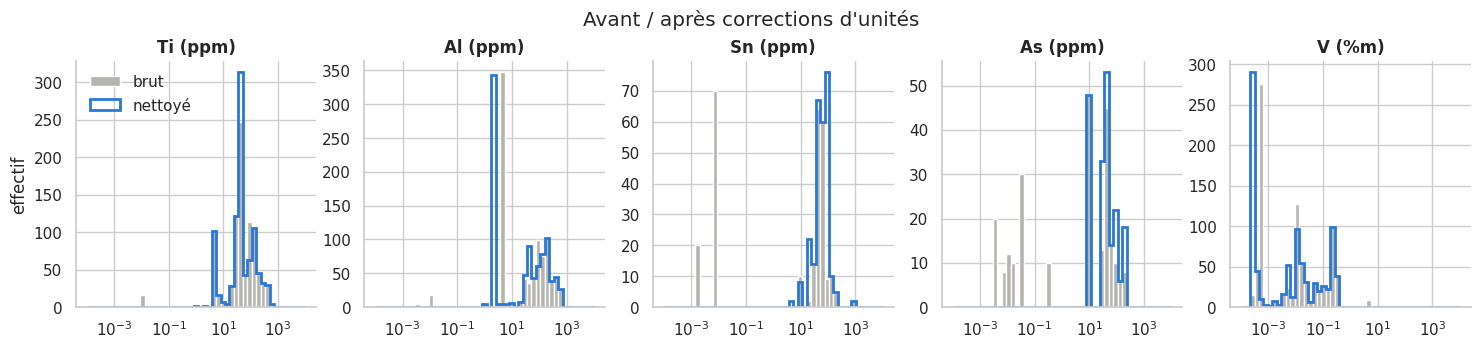

In [19]:
raw_num = raw.apply(lambda s: s.map(first_number) if s.name in NUM_COLS else s)
fig, axes = plt.subplots(1, 5, figsize=(18, 3.2))
bins = np.logspace(-4, 4, 50)
for ax, c in zip(axes, ["Ti", "Al", "Sn", "As", "V"]):
    ax.hist(raw_num[c][raw_num[c] > 0], bins=bins, color=C_GREY, label="brut")
    ax.hist(df[c][df[c] > 0], bins=bins, histtype="step", lw=2, color=C_BLUE, label="nettoyé")
    ax.set_xscale("log"); ax.set_title(f"{c} ({UNITS[c]})")
axes[0].set_ylabel("effectif"); axes[0].legend()
plt.suptitle("Avant / après corrections d'unités", y=1.04)
savefig("nettoyage_unites"); plt.show()

Les groupes de valeurs aberrantes ont disparu. Les petits décalages des pics principaux (ex. Al : 5 → 2,5 ppm) sont l'effet attendu du remplacement de `<5` par 2,5 (section 3.2).

## 3.6 Variables catégorielles : type de soudage, courant, polarité

**Constat** :

In [20]:
src_n = df.groupby("WeldType")["WeldID"].apply(lambda w: w.str.split("-").str[0].nunique())
wt = pd.DataFrame({"nb lignes": df["WeldType"].value_counts(), "nb sources": src_n})
wt = wt.join(df.groupby("WeldType")["HeatInput"].median().rename("énergie médiane (kJ/mm)"))
wt.sort_values("nb lignes", ascending=False)

,nb lignes,nb sources,énergie médiane (kJ/mm)
WeldType,,,
MMA,1140,93,1.000
SA,261,35,2.925
TSA,87,3,4.400
FCA,87,2,2.040
ShMA,40,1,1.000
NGSAW,18,2,2.000
NGGMA,7,2,3.600
GMAA,4,1,1.250
GTAA,4,1,1.650


**Constat** : 10 modalités, dont 5 ont **moins de 20 lignes** et viennent d'**une ou deux publications** (le nombre de sources est ici approximatif : l'identification des publications est affinée en 4.2, ce qui ne peut que le diminuer).

**Question** : faut-il garder les 10 modalités ?

**Raisonnement** : avec 4 lignes issues d'une seule publication, un modèle ne peut pas distinguer l'effet du *procédé* de l'effet de la *publication* (autre laboratoire, autres matériaux). En validation croisée, certains plis n'en contiendraient aucune. Il faut regrouper, mais selon un critère **physique**, pas seulement par effectif :

+ la documentation dit explicitement que **ShMA = MMA** (électrode enrobée) ;
+ SA, TSA (tandem), NGSAW (chanfrein étroit) sont des variantes de **l'arc submergé** (le bain est protégé par un flux en poudre) ; SAA n'est pas documenté, on suppose « arc submergé automatique » (*hypothèse*) ;
+ GMAA, GTAA, NGGMA sont des procédés **sous protection gazeuse** ;
+ FCA (fil fourré) est un procédé à part entière, avec assez de lignes (87).

**Vérification** : si ce regroupement a un sens physique, les groupes doivent se distinguer par leur énergie de soudage (tableau ci-dessus) : l'électrode enrobée est à ~1 kJ/mm, l'arc submergé entre 1,4 et 4,4 kJ/mm, le fil fourré à ~2 kJ/mm. C'est cohérent, à une nuance près : SAA (1,4) et NGSAW (2,0) sont plus bas que SA/TSA, ce qui rend l'hypothèse sur SAA fragile, mais cela ne concerne que 4 lignes.

In [21]:
df["WeldType"] = df["WeldType"].replace({"ShMA": "MMA"})
WELD_GROUP = {"MMA": "Électrode enrobée",
              "SA": "Arc submergé", "SAA": "Arc submergé", "TSA": "Arc submergé", "NGSAW": "Arc submergé",
              "FCA": "Fil fourré", "GMAA": "Sous gaz", "GTAA": "Sous gaz", "NGGMA": "Sous gaz"}
df["WeldGroup"] = df["WeldType"].map(WELD_GROUP)
print(df["WeldGroup"].value_counts().to_dict())
decide("3.6", "ShMA -> MMA ; 4 familles : électrode enrobée / arc submergé / fil fourré / sous gaz",
       "modalités rares (4-18 lignes, 1-2 sources) : effet procédé indissociable de l'effet publication ; "
       "regroupement par mode de protection du bain, cohérent avec l'énergie de soudage",
       "garder 10 modalités (instable en CV) ; regrouper par effectif seul (sans sens physique)")

{'Électrode enrobée': 1180, 'Arc submergé': 370, 'Fil fourré': 87, 'Sous gaz': 15}
DÉCISION [3.6] ShMA -> MMA ; 4 familles : électrode enrobée / arc submergé / fil fourré / sous gaz
   pourquoi : modalités rares (4-18 lignes, 1-2 sources) : effet procédé indissociable de l'effet publication ; regroupement par mode de protection du bain, cohérent avec l'énergie de soudage
   alternatives écartées : garder 10 modalités (instable en CV) ; regrouper par effectif seul (sans sens physique)


Pour AC/DC et la polarité, une valeur `0` apparaît dans la polarité. **Hypothèse** : c'est le courant alternatif (qui n'a pas de polarité). **Vérification** par un tableau croisé :

In [22]:
pd.crosstab(df["Polarity"].fillna("manquant"), df["AC_DC"].fillna("manquant"))

AC_DC,AC,DC,manquant
Polarity,,,
+,4,1388,59
-,0,7,0
0,38,0,0
manquant,0,0,156


Les 38 lignes de polarité `0` sont exactement des lignes en courant alternatif : l'hypothèse est confirmée. Par ailleurs, DC+ représente la quasi-totalité des cas renseignés : ces deux variables apportent **très peu d'information**. On les garde pour l'instant (elles ne coûtent rien aux modèles à base d'arbres), mais elles sont candidates à la suppression.

In [23]:
decide("3.6", "Polarité '0' = courant alternatif ; AC/DC et polarité conservées mais jugées peu informatives",
       "tableau croisé : polarité 0 <=> AC dans 38/38 cas ; DC+ très majoritaire")

DÉCISION [3.6] Polarité '0' = courant alternatif ; AC/DC et polarité conservées mais jugées peu informatives
   pourquoi : tableau croisé : polarité 0 <=> AC dans 38/38 cas ; DC+ très majoritaire
   alternatives écartées : —


# 4. Valeurs manquantes

## 4.1 Combien, et où ?

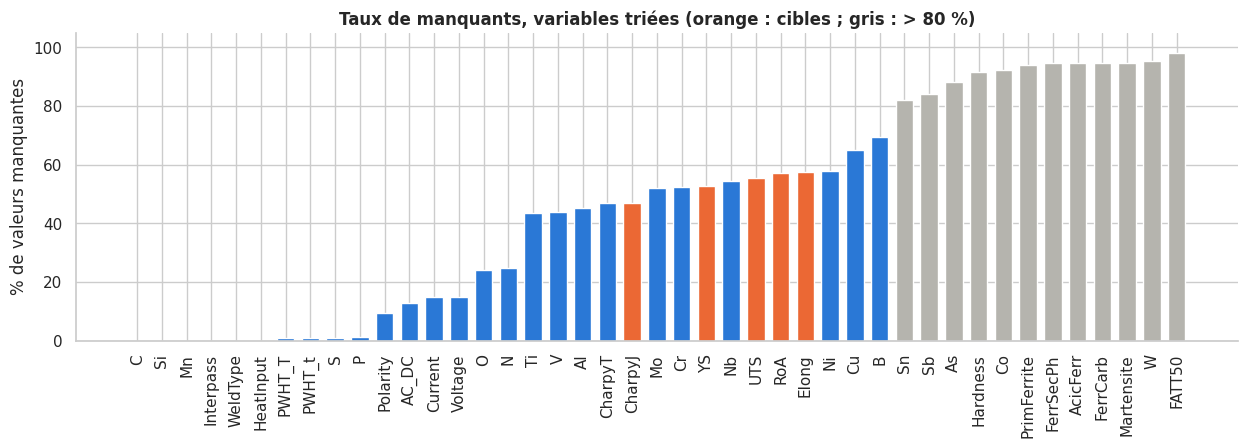

In [24]:
miss = df[ALL_VARS].isna().mean().mul(100).sort_values()
fig, ax = plt.subplots(figsize=(15, 4))
colors = [C_ORANGE if c in TARGETS else (C_GREY if miss[c] > 80 else C_BLUE) for c in miss.index]
ax.bar(range(len(miss)), miss.values, color=colors, width=0.7)
ax.set_xticks(range(len(miss))); ax.set_xticklabels(miss.index, rotation=90)
ax.set_ylabel("% de valeurs manquantes"); ax.set_ylim(0, 105)
ax.set_title("Taux de manquants, variables triées (orange : cibles ; gris : > 80 %)")
savefig("manquants_taux"); plt.show()

**Constat** : une fois triés, les taux montrent un **saut** entre ~70 % (B) et ~82 % (Sn) : il n'y a presque aucune variable entre les deux.

**Question** : à partir de quand une variable est-elle trop manquante pour être utile ?

Le taux ne suffit pas : ce qui compte aussi, c'est **combien de publications différentes** renseignent la variable. Si seules 8 publications donnent l'arsenic, un modèle qui l'utilise apprendra surtout à reconnaître ces 8 publications, pas l'effet de l'arsenic.

## 4.2 Parenthèse nécessaire : identifier la publication d'origine

Pour compter les publications qui renseignent chaque variable, il faut d'abord savoir de quelle publication vient chaque ligne. La colonne `WeldID` semble commencer par un nom d'auteur. **Première tentative** : prendre ce qui précède le premier tiret.

In [25]:
attempt1 = df["WeldID"].str.split("-").str[0]
vc = attempt1.value_counts()
print("Nombre de 'sources' :", len(vc), "| dont", (vc == 1).sum(), "sources d'une seule ligne")
print("Exemples de sources d'une seule ligne :", list(vc[vc == 1].index[:8]))

Nombre de 'sources' : 135 | dont 79 sources d'une seule ligne
Exemples de sources d'une seule ligne : ['KocakPEv', 'EvansLetterCo+', 'EvansLetterCo+ch1', 'EvansLetterCo+ch2', 'EvansLetterCo+1Ni', 'EvansLetterCo+1Nich1', 'EvansLetterCo+1Nich2', 'EvansLetterCo+2Ni']


**Constat** : beaucoup de « sources » d'une seule ligne, dont les noms montrent que la règle échoue : `EvansLetterC+1Ni`, `EvansLetterCo+2Cr`… sont des soudures d'une même publication (*EvansLetter*) dont l'identifiant n'a pas de tiret. On voit aussi `KocakPEv` à côté de `KocakPREv` (faute de frappe probable) et une série `p9`, `p10`, … `p36` de 2 lignes chacune, dont on ignore l'origine.

**Décision** : on corrige ces cas et on regroupe la série `p…` en une seule source (*hypothèse* : même compilation). Ce niveau « auteur / série » est un peu grossier (Evans a publié de nombreux articles), mais pour les usages prévus (validation croisée par source) regrouper un peu trop est **prudent** : cela rend l'évaluation plus exigeante, jamais plus optimiste.

Nombre de sources après correction : 34


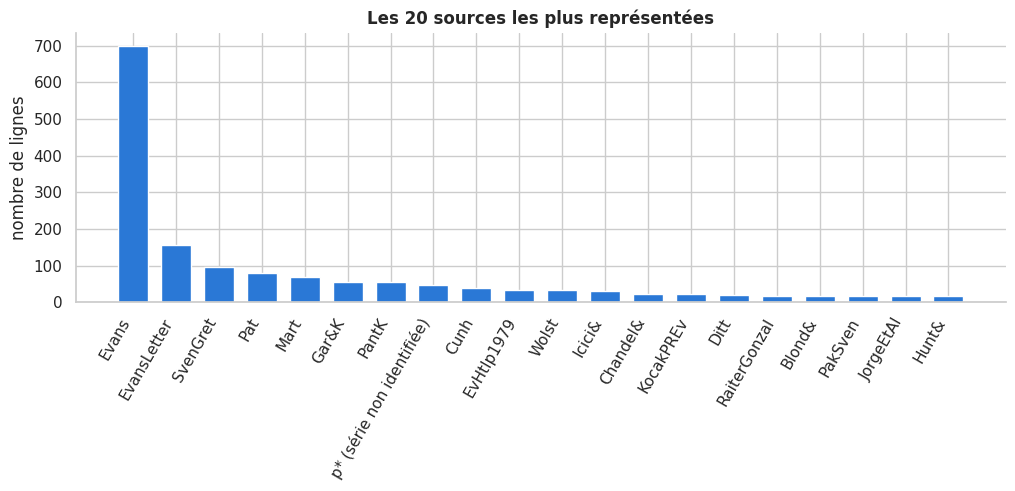

Part des lignes d'Evans (Evans + EvansLetter + EvHt…) : 54%
DÉCISION [4.2] Source = préfixe de WeldID, corrigé (EvansLetter…, p*, KocakPEv) -> 34 sources
   pourquoi : la règle naïve créait des dizaines de fausses sources d'une ligne
   alternatives écartées : garder les 135 'sources' naïves


In [26]:
def extract_source(wid):
    s = wid.split("-")[0]
    if s.startswith("EvansLetter"):
        return "EvansLetter"
    if re.fullmatch(r"p\d+", s):
        return "p* (série non identifiée)"
    if s == "KocakPEv":
        return "KocakPREv"
    return s

df["Source"] = df["WeldID"].map(extract_source)
src_counts = df["Source"].value_counts()
print("Nombre de sources après correction :", len(src_counts))

fig, ax = plt.subplots(figsize=(12, 3.5))
top = src_counts.head(20)
ax.bar(range(len(top)), top.values, color=C_BLUE, width=0.7)
ax.set_xticks(range(len(top))); ax.set_xticklabels(top.index, rotation=60, ha="right")
ax.set_ylabel("nombre de lignes"); ax.set_title("Les 20 sources les plus représentées")
savefig("sources"); plt.show()
print(f"Part des lignes d'Evans (Evans + EvansLetter + EvHt…) : {df['Source'].str.startswith('Ev').mean():.0%}")
decide("4.2", f"Source = préfixe de WeldID, corrigé (EvansLetter…, p*, KocakPEv) -> {len(src_counts)} sources",
       "la règle naïve créait des dizaines de fausses sources d'une ligne",
       "garder les 135 'sources' naïves")

**Constat** : la base est très **déséquilibrée** : Evans fournit environ la moitié des lignes. Un modèle risque de refléter surtout les soudures d'Evans (aciers C-Mn à l'électrode enrobée). À garder en tête pour l'interprétation.

Revenons à la question de la section 4.1 : combien de publications renseignent chaque variable ?

In [27]:
cov = pd.DataFrame({"% manquant": miss.round(1),
                    "nb valeurs": df[miss.index].notna().sum(),
                    "nb sources qui la renseignent": [df["Source"][df[c].notna()].nunique() for c in miss.index]})
cov[cov["% manquant"] > 40]

,% manquant,nb valeurs,nb sources qui la renseignent
Ti,43.5,934,18
V,43.8,928,20
Al,45.2,905,17
CharpyT,46.9,878,15
CharpyJ,46.9,878,15
Mo,52.0,793,27
Cr,52.5,784,27
YS,52.8,780,30
Nb,54.5,752,16
UTS,55.3,738,29


## 4.3 Quelles variables écarter ?

**Constat** : au-delà de 80 % de manquants, les variables ne sont renseignées que par une poignée des 34 publications : 8 à 10 pour Sn, As, Sb ; 4–5 pour Co, W ; 1 à 5 pour dureté, FATT et microstructure. Les éléments entre 40 et 65 % de manquants (Ti, V, Al, Mo, Cr, Nb, Ni, Cu) viennent de 16 à 27 publications : l'information est bien plus diversifiée.

**Décision** : on écarte les variables à plus de 80 % de manquants. Le seuil de 80 % n'est pas magique, mais il tombe **dans le saut** observé : un seuil entre 71 et 81 % donnerait exactement la même liste.

<div class="alert alert-block alert-warning">

**Un cas limite : le bore.** B n'a « que » 70 % de manquants, donc il passe le seuil, mais il ne vient que de **8 publications**, autant que As ou Sb. Nos deux critères (taux et nombre de sources) ne sont donc pas d'accord. On le garde **provisoirement** pour deux raisons : le bore est connu pour jouer un rôle important sur la ténacité des soudures (avec le titane, il favorise la ferrite aciculaire), et son information est presque binaire (83 % de valeurs « non détecté », section 3.2). En contrepartie, on **comparera en validation croisée les modèles avec et sans B**.

</div>

In [28]:
DROP = [c for c in ALL_VARS if miss[c] > 80]
print("Variables écartées :", DROP)
decide("4.3", f"Écarter les variables > 80 % manquantes : {', '.join(DROP)}",
       "le seuil tombe dans un saut naturel des taux (70 -> 82 %) ; ces variables ne viennent que de 1 à 10 sources "
       "sur 34 : un modèle apprendrait la source, pas l'effet physique. B (8 sources) gardé provisoirement, à tester en CV",
       "tout garder et imputer (on inventerait > 80 % des valeurs)")

Variables écartées : ['Co', 'W', 'Sn', 'As', 'Sb', 'Hardness', 'FATT50', 'PrimFerrite', 'FerrSecPh', 'AcicFerr', 'Martensite', 'FerrCarb']
DÉCISION [4.3] Écarter les variables > 80 % manquantes : Co, W, Sn, As, Sb, Hardness, FATT50, PrimFerrite, FerrSecPh, AcicFerr, Martensite, FerrCarb
   pourquoi : le seuil tombe dans un saut naturel des taux (70 -> 82 %) ; ces variables ne viennent que de 1 à 10 sources sur 34 : un modèle apprendrait la source, pas l'effet physique. B (8 sources) gardé provisoirement, à tester en CV
   alternatives écartées : tout garder et imputer (on inventerait > 80 % des valeurs)


## 4.4 Les manquants sont-ils aléatoires ?

C'est important pour choisir comment les remplacer plus tard. On affiche la carte des manquants avec les lignes **triées par publication** : si les manquants dépendent de la publication, on doit voir des blocs.

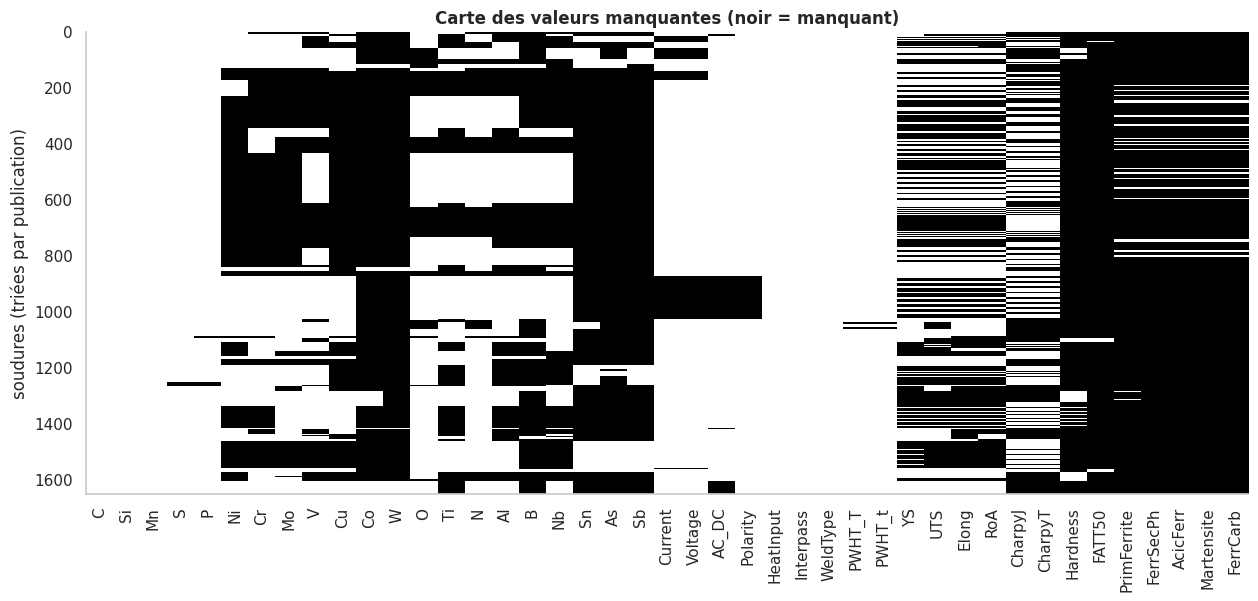

In [29]:
order = df["Source"].sort_values(kind="stable").index
fig, ax = plt.subplots(figsize=(15, 6))
ax.imshow(df.loc[order, ALL_VARS].isna().values, aspect="auto", cmap="Greys", interpolation="nearest")
ax.grid(False)
ax.set_xticks(range(len(ALL_VARS))); ax.set_xticklabels(ALL_VARS, rotation=90)
ax.set_ylabel("soudures (triées par publication)")
ax.set_title("Carte des valeurs manquantes (noir = manquant)")
savefig("manquants_carte"); plt.show()

**Constat** : les manquants forment des **blocs horizontaux** : une publication mesure un élément pour toutes ses soudures, ou pour aucune. Les manquants ne sont donc pas aléatoires : ils dépendent de la source.

**Hypothèse** : quand un auteur ne rapporte pas le nickel ou le molybdène, c'est souvent qu'il ne l'a pas **ajouté volontairement** (il ne s'y intéresse pas). La vraie teneur serait alors faible (résiduelle).

**Ce qu'on peut vérifier** : quand l'élément *est* rapporté, est-il souvent proche de zéro ?

In [30]:
for c in ["Ni", "Cr", "Mo", "Cu", "V"]:
    s = df[c].dropna()
    print(f"{c:3s} rapporté sur {len(s):4d} lignes | médiane = {s.median():.3f} %m | "
          f"{(s <= 0.05).mean():.0%} des valeurs ≤ 0,05 %m")

Ni  rapporté sur  697 lignes | médiane = 0.067 %m | 46% des valeurs ≤ 0,05 %m
Cr  rapporté sur  784 lignes | médiane = 0.530 %m | 36% des valeurs ≤ 0,05 %m
Mo  rapporté sur  793 lignes | médiane = 0.340 %m | 42% des valeurs ≤ 0,05 %m
Cu  rapporté sur  578 lignes | médiane = 0.030 %m | 57% des valeurs ≤ 0,05 %m
V   rapporté sur  928 lignes | médiane = 0.005 %m | 77% des valeurs ≤ 0,05 %m


Pour Ni, Cu, V, une majorité des valeurs rapportées sont déjà quasi nulles, ce qui rend l'hypothèse plausible. Mais ce n'est **pas une preuve** : il se peut que les soudures non renseignées soient différentes de celles qui le sont.

**Décision** : on ne tranche pas ici. L'imputation sera faite **dans la validation croisée** et plusieurs stratégies seront comparées (médiane, 0, imputation itérative), toujours avec un **indicateur de manquant**, qui permet au modèle d'apprendre si « non rapporté » a un effet.

In [31]:
decide("4.4", "Manquants traités comme non aléatoires : stratégie d'imputation choisie par validation croisée, "
              "avec indicateurs de manquant",
       "manquants structurés par publication ; l'hypothèse 'non rapporté = non ajouté' est plausible mais non prouvée",
       "fixer maintenant une imputation unique ; supprimer les lignes incomplètes (voir 4.5)")

DÉCISION [4.4] Manquants traités comme non aléatoires : stratégie d'imputation choisie par validation croisée, avec indicateurs de manquant
   pourquoi : manquants structurés par publication ; l'hypothèse 'non rapporté = non ajouté' est plausible mais non prouvée
   alternatives écartées : fixer maintenant une imputation unique ; supprimer les lignes incomplètes (voir 4.5)


## 4.5 Peut-on simplement garder les lignes complètes ?

C'est la solution la plus simple ; vérifions ce qu'il resterait :

In [32]:
KEEP_INPUTS = [c for c in CHEM_PCT + CHEM_PPM + ["Current", "Voltage", "HeatInput", "Interpass"] + PWHT
               if c not in DROP]
cc = df[KEEP_INPUTS].dropna()
print(f"Lignes complètes sur les {len(KEEP_INPUTS)} entrées numériques conservées : {len(cc)} sur {len(df)}")
print("Sources de ces lignes :", df["Source"][cc.index].value_counts().to_dict())

Lignes complètes sur les 22 entrées numériques conservées : 12 sur 1652
Sources de ces lignes : {'Wats': 12}


**Constat** : il ne resterait qu'une douzaine de lignes, toutes issues d'**une seule publication**. Supprimer les lignes incomplètes est donc impossible : l'**imputation est indispensable**, pour les modèles comme pour l'ACP (section 9).

## 4.6 Les cibles sont-elles connues en même temps ?

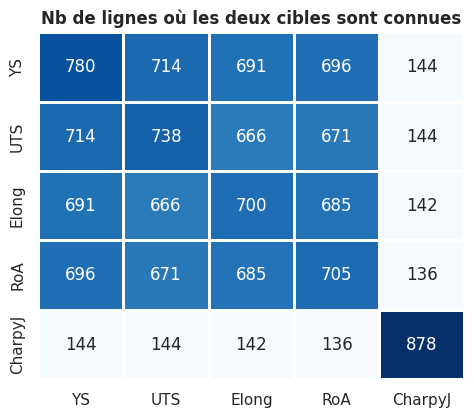

Traction seule : 668 | Charpy seul : 734 | les deux : 144 | aucune cible : 106


In [33]:
known = df[TARGETS].notna().astype(int)
cooc = known.T @ known
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cooc, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax, linewidths=2, linecolor="white")
ax.set_title("Nb de lignes où les deux cibles sont connues")
savefig("cibles_cooccurrence"); plt.show()

traction = df[["YS", "UTS", "Elong", "RoA"]].notna().any(axis=1)
charpy = df["CharpyJ"].notna()
print(f"Traction seule : {(traction & ~charpy).sum()} | Charpy seul : {(charpy & ~traction).sum()} "
      f"| les deux : {(traction & charpy).sum()} | aucune cible : {(~traction & ~charpy).sum()}")

**Constat** : les essais de traction (YS, UTS, Elong, RoA) sont presque toujours connus ensemble, mais **presque jamais sur la même ligne que l'essai Charpy**. Chaque cible n'est connue que sur 42 à 53 % des lignes.

**Conséquences** :
+ on entraînera **un modèle par cible**, chacun sur les lignes où sa cible est connue ;
+ la base est **partiellement étiquetée** : pour une cible donnée, les autres lignes ont des entrées mais pas de sortie. C'est exactement la situation du **semi-supervisé** demandé par le sujet ;
+ pourquoi traction et Charpy sont-ils sur des lignes séparées ? La section 5 l'explique.

# 5. Structure de la base : lignes répétées

## 5.1 Des lignes qui se répètent

En parcourant les premières lignes (section 1.2), on remarque des lignes consécutives avec **exactement la même composition**. Regardons un exemple :

In [34]:
ex = df[df["WeldID"].str.startswith("Evans-Ni/CMn-1990/1991-0A")]
ex[["WeldID", "C", "Mn", "Ni", "HeatInput", "PWHT_T", "PWHT_t", "YS", "UTS", "Elong", "CharpyT", "CharpyJ"]]

,WeldID,C,Mn,Ni,HeatInput,PWHT_T,PWHT_t,YS,UTS,Elong,CharpyT,CharpyJ
0,Evans-Ni/CMn-1990/1991-0Aaw,0.037,0.65,0.0,1.0,250.0,14.0,392.0,466.0,31.9,NaN,NaN
1,Evans-Ni/CMn-1990/1991-0Aawch,0.037,0.65,0.0,1.0,0.0,0.0,NaN,NaN,NaN,-28.0,100.0
2,Evans-Ni/CMn-1990/1991-0Aht,0.037,0.65,0.0,1.0,580.0,2.0,370.0,456.0,35.2,-38.0,100.0


**Interprétation** : c'est **une seule soudure** décrite sur trois lignes, distinguées par le suffixe du `WeldID` :
+ `aw` (*as-welded*) : l'éprouvette de **traction** ;
+ `awch` (*as-welded, Charpy*) : l'éprouvette de **résilience**, même composition, même procédé ;
+ `ht` (*heat treated*) : la même soudure après un revenu à 580 °C.

C'est ce qui explique que traction et Charpy soient sur des lignes séparées (section 4.6).

## 5.2 Quelle clé pour « la même soudure » ?

**Question** : comment regrouper les lignes qui correspondent à la même soudure physique ?

**Choix de la clé** : deux lignes décrivent le même dépôt de soudure si elles ont la même **composition** et les mêmes **paramètres de procédé** (courant, tension, énergie, T entre passes, type). On n'inclut **pas** :
+ le `WeldID`, justement différent entre `aw` et `awch` ;
+ le traitement post-soudage, car une soudure revenue (`ht`) reste le même dépôt : si la version brute est dans l'apprentissage et la version revenue dans le test, le modèle a déjà « vu » cette composition.

Les valeurs manquantes sont codées par une valeur spéciale pour que deux lignes avec le même motif de manquants puissent être reconnues identiques.

In [35]:
KEY_COLS = ["C", "Si", "Mn", "S", "P", "Ni", "Cr", "Mo", "V", "Cu", "O", "Ti", "N", "Al", "B", "Nb",
            "Current", "Voltage", "HeatInput", "Interpass", "WeldType"]
key = df[KEY_COLS].round(5).fillna(-999).astype(str).agg("|".join, axis=1)
df["WeldGroupID"] = pd.factorize(key)[0]

sizes = df["WeldGroupID"].value_counts()
print(f"{len(df)} lignes -> {df['WeldGroupID'].nunique()} soudures distinctes")
print("Nombre de lignes par soudure :", sizes.value_counts().sort_index().to_dict())

1652 lignes -> 624 soudures distinctes
Nombre de lignes par soudure : {1: 220, 2: 125, 3: 150, 4: 48, 5: 17, 6: 28, 7: 27, 8: 2, 9: 1, 10: 3, 11: 1, 12: 1, 20: 1}


**Vérification** : si la clé est trop grossière, elle pourrait fusionner des soudures différentes de publications différentes ayant par hasard la même composition. Comptons les groupes qui mélangent plusieurs sources :

In [36]:
multi_src = df.groupby("WeldGroupID")["Source"].nunique()
print("Groupes couvrant plusieurs sources :", (multi_src > 1).sum(), "sur", len(multi_src))

Groupes couvrant plusieurs sources : 0 sur 624


Aucun groupe ne mélange deux publications : la clé ne fusionne pas par erreur des soudures d'origines différentes. *(Avec la règle naïve d'identification des sources de 4.2, on trouvait 26 groupes « multi-sources » : c'étaient les fausses sources EvansLetter, ce qui confirme a posteriori la correction faite en 4.2.)*

Autre vérification : la clé est-elle **trop fine** ? Deux lignes d'une même soudure pourraient différer par un arrondi. Les tailles de groupe (1 à 20 lignes, surtout 1 à 3) sont cohérentes avec le schéma traction / Charpy / revenu, et on a arrondi à $10^{-5}$ pour absorber les écarts de représentation des nombres.

In [37]:
decide("5.2", "WeldGroupID = soudure physique (composition + procédé, sans WeldID ni traitement thermique)",
       "une même soudure est répartie sur plusieurs lignes (traction / Charpy / revenue)",
       "considérer les lignes comme indépendantes ; inclure le traitement thermique dans la clé (fuite via la composition)")

DÉCISION [5.2] WeldGroupID = soudure physique (composition + procédé, sans WeldID ni traitement thermique)
   pourquoi : une même soudure est répartie sur plusieurs lignes (traction / Charpy / revenue)
   alternatives écartées : considérer les lignes comme indépendantes ; inclure le traitement thermique dans la clé (fuite via la composition)


## 5.3 Un détail qui empêche de relier traction et Charpy

Dans l'exemple ci-dessus, la ligne de traction `aw` a un traitement de **250 °C pendant 14 h**, alors que la ligne Charpy `awch` n'a **aucun traitement**. Est-ce un cas isolé ou une convention ? Croisons, pour les lignes d'Evans, le type d'essai et la température de traitement :

In [38]:
ev = df[df["Source"].str.startswith("Ev")]
essai = np.select([ev["YS"].notna(), ev["CharpyJ"].notna()], ["traction", "Charpy"], "autre")
pd.crosstab(pd.Series(essai, index=ev.index, name="essai"), ev["PWHT_T"].fillna(-1).rename("PWHT_T (°C)"))

PWHT_T (°C),0.0,250.0,500.0,580.0,750.0
essai,,,,,
Charpy,206,104,0,111,24
autre,44,0,0,0,0
traction,20,229,4,125,21


**Constat** : chez Evans, les éprouvettes de traction non revenues sont presque toutes à 250 °C (229 contre 20 à 0 °C). Les éprouvettes Charpy non revenues sont majoritairement notées 0 °C, mais une partie est à 250 °C : la convention d'écriture varie d'une série à l'autre. L'étuvage à 250 °C est donc une **convention de préparation**, pas un traitement choisi pour modifier la soudure : avant un essai de traction, on étuve l'éprouvette pour éliminer l'hydrogène, qui fragilise l'acier et fausserait la mesure. Un étuvage à 250 °C est trop froid pour modifier la microstructure : un revenu demande au moins 450–500 °C.

**Décision** : pour identifier l'**état métallurgique** d'une soudure, on considère qu'un traitement inférieur à 400 °C équivaut à l'état brut. Le seuil de 400 °C est choisi dans le **vide** des valeurs observées (aucune température entre 250 et 482 °C, voir 6.3) : tout seuil dans cet intervalle donnerait le même résultat.

In [39]:
pw_T = df["PWHT_T"].where(df["PWHT_T"] >= 400, 0).fillna(-999)
pw_t = df["PWHT_t"].where(df["PWHT_T"] >= 400, 0).fillna(-999)
df["WeldStateID"] = pd.factorize(key + "|" + pw_T.astype(str) + "|" + pw_t.astype(str))[0]

g = df.groupby("WeldStateID").agg(trac=("YS", lambda s: s.notna().any()),
                                  chp=("CharpyJ", lambda s: s.notna().any()))
print(f"{df['WeldStateID'].nunique()} états (soudure + traitement) ; "
      f"{(g.trac & g.chp).sum()} ont à la fois traction et Charpy (contre {(traction & charpy).sum()} lignes avant regroupement)")
decide("5.3", "WeldStateID = soudure + traitement thermique, un étuvage < 400 °C étant assimilé à l'état brut",
       "convention d'Evans (étuvage anti-hydrogène des éprouvettes de traction, 229/249) ; 250 °C ne modifie pas "
       "la microstructure ; seuil placé dans le vide 250-482 °C",
       "considérer 0 °C et 250 °C comme deux états différents (empêche de relier traction et Charpy)")

829 états (soudure + traitement) ; 429 ont à la fois traction et Charpy (contre 144 lignes avant regroupement)
DÉCISION [5.3] WeldStateID = soudure + traitement thermique, un étuvage < 400 °C étant assimilé à l'état brut
   pourquoi : convention d'Evans (étuvage anti-hydrogène des éprouvettes de traction, 229/249) ; 250 °C ne modifie pas la microstructure ; seuil placé dans le vide 250-482 °C
   alternatives écartées : considérer 0 °C et 250 °C comme deux états différents (empêche de relier traction et Charpy)


<div class="alert alert-block alert-danger">

**Conséquence majeure pour la validation croisée.** Une validation croisée classique (`KFold`) mettrait souvent la ligne de traction d'une soudure dans l'apprentissage et sa ligne revenue dans le test : le modèle « reconnaîtrait » la composition et l'erreur serait **sous-estimée**. Il faudra une **validation croisée groupée** (`GroupKFold`, `groups = WeldGroupID`), et en complément un découpage par `Source` pour tester la généralisation à un nouveau laboratoire.

</div>

In [40]:
decide("5.3", "Validation croisée groupée par WeldGroupID (et test complémentaire par Source)",
       "lignes non indépendantes : même soudure sur plusieurs lignes",
       "KFold classique (fuite d'information, erreur optimiste)")

DÉCISION [5.3] Validation croisée groupée par WeldGroupID (et test complémentaire par Source)
   pourquoi : lignes non indépendantes : même soudure sur plusieurs lignes
   alternatives écartées : KFold classique (fuite d'information, erreur optimiste)


# 6. Variables d'entrée

## 6.1 Ordres de grandeur

In [41]:
IN_NUM = [c for c in CHEM_PCT + CHEM_PPM + ["Current", "Voltage", "HeatInput", "Interpass"] + PWHT if c not in DROP]
desc = df[IN_NUM].describe().T[["count", "mean", "std", "min", "50%", "max"]]
desc.insert(0, "unité", [UNITS[c] for c in IN_NUM])
desc["asymétrie"] = df[IN_NUM].skew().round(2)
desc

,unité,count,mean,std,min,50%,max,asymétrie
C,%m,1652.0,0.076,0.024,0.029,0.074,0.180,0.83
Si,%m,1652.0,0.329,0.112,0.040,0.320,1.140,1.62
Mn,%m,1652.0,1.203,0.382,0.270,1.270,2.250,0.08
S,%m,1638.0,0.009,0.005,0.001,0.007,0.036,1.91
P,%m,1632.0,0.011,0.006,0.002,0.010,0.075,2.70
Ni,%m,697.0,0.415,0.787,0.000,0.067,3.500,2.41
Cr,%m,784.0,2.101,3.027,0.000,0.530,10.200,1.55
Mo,%m,793.0,0.479,0.477,0.000,0.340,1.500,0.27
V,%m,928.0,0.049,0.086,0.000,0.005,0.320,1.69
Cu,%m,578.0,0.172,0.323,0.000,0.030,1.630,2.77


**Constat** : les écarts-types vont de ~0,005 (S, P en %m) à ~200–300 (courant en A, température de traitement en °C), soit un facteur $10^5$.

**Conséquence** : toute méthode fondée sur des **distances** ou des **variances** (ACP, kNN, SVM, régression pénalisée, réseaux de neurones) serait dominée par les variables de grande amplitude numérique, uniquement à cause de leur unité. Il faudra **standardiser** pour ces méthodes (démonstration en 9.2). Les arbres de décision, qui ne comparent qu'une variable à la fois à un seuil, n'en ont pas besoin.

**Constat 2** : plusieurs variables sont très **asymétriques** (asymétrie > 2). Cela oriente deux choix : utiliser des corrélations de rang (section 8) et tester une transformation $\log(1+x)$ pour les modèles linéaires.

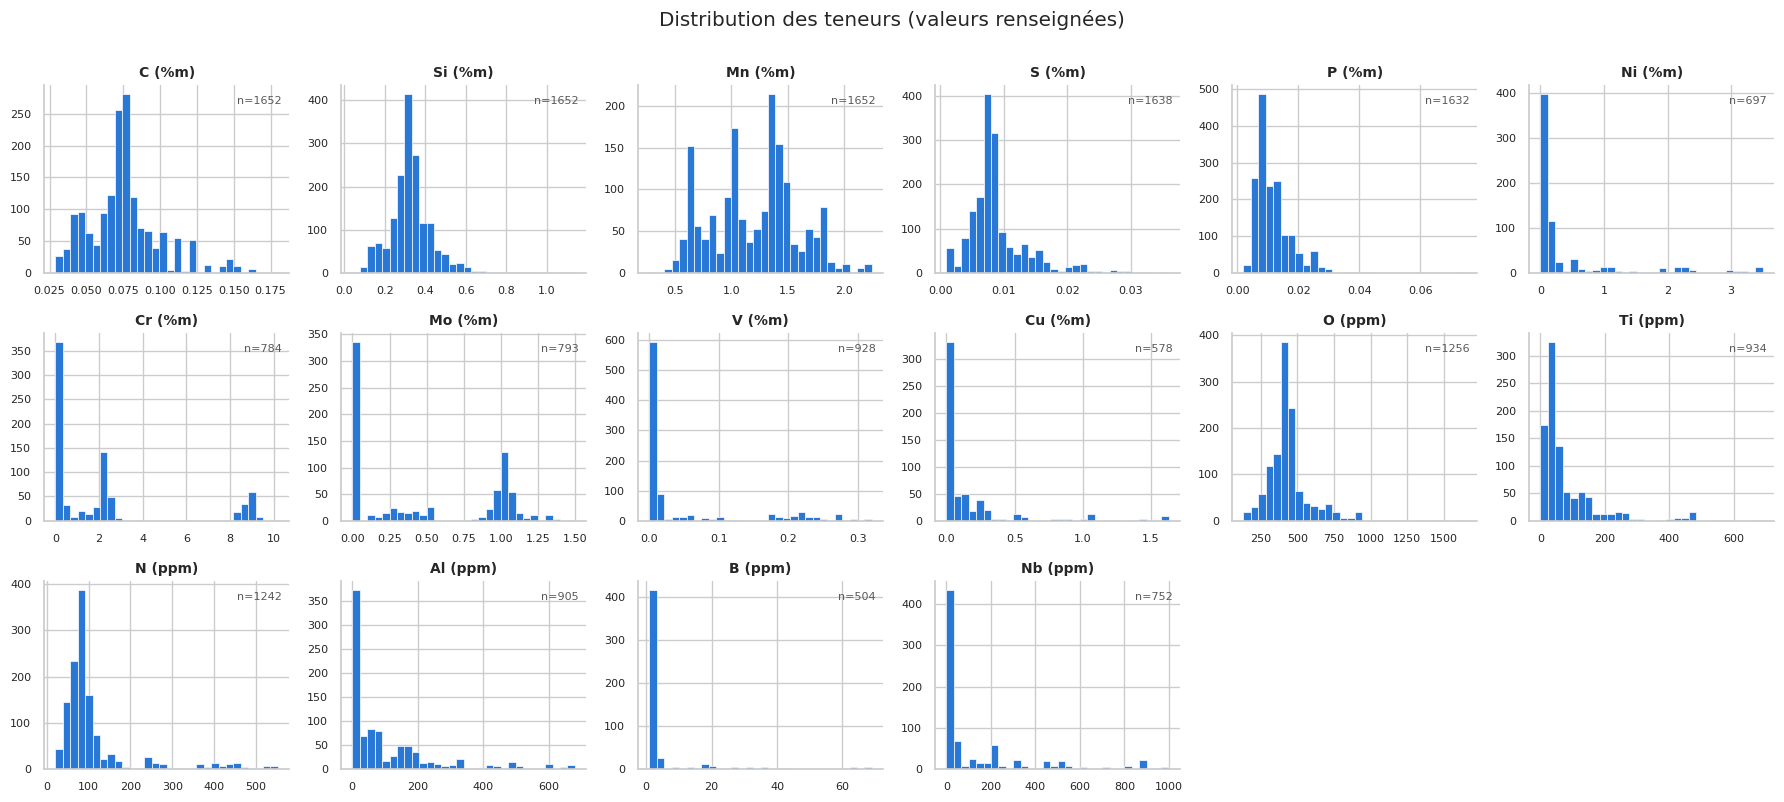

In [42]:
fig, axes = plt.subplots(3, 6, figsize=(18, 8))
for ax, c in zip(axes.ravel(), [c for c in CHEM_PCT + CHEM_PPM if c not in DROP]):
    s = df[c].dropna()
    ax.hist(s, bins=30, color=C_BLUE, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{c} ({UNITS[c]})", fontsize=10)
    ax.text(0.97, 0.9, f"n={len(s)}", transform=ax.transAxes, ha="right", fontsize=8, color="0.35")
    ax.tick_params(labelsize=8)
for ax in axes.ravel()[len([c for c in CHEM_PCT + CHEM_PPM if c not in DROP]):]:
    ax.axis("off")
plt.suptitle("Distribution des teneurs (valeurs renseignées)", y=1.0)
plt.tight_layout(); savefig("distrib_composition"); plt.show()

**Lecture** :
+ C, Si, Mn, S, P, O, N : une seule bosse, compatible avec des aciers au carbone-manganèse faiblement alliés.
+ Ni, Cr, Mo, V, Cu, Nb, Ti, Al, B : un **pic à zéro** (élément non ajouté) et une **queue** (élément ajouté volontairement).
+ Cr et Mo ont un second groupe bien séparé (Cr ≈ 2,25 et ≈ 9 %m, Mo ≈ 1 %m) : ce sont les nuances normalisées **2¼Cr-1Mo et 9Cr-1Mo**, des aciers résistant au fluage. On a donc au moins deux « populations » d'aciers dans la base : on le vérifiera avec l'ACP.

## 6.2 Procédé

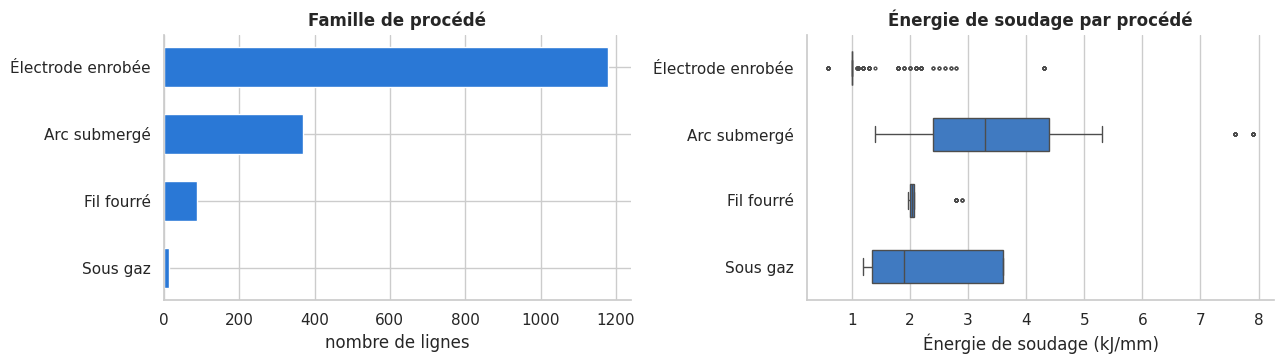

Corrélation (Spearman) énergie – courant : 0.8


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
order_g = df["WeldGroup"].value_counts().index
counts = df["WeldGroup"].value_counts()
axes[0].barh(counts.index[::-1], counts.values[::-1], color=C_BLUE, height=0.6)
axes[0].set_title("Famille de procédé"); axes[0].set_xlabel("nombre de lignes")
sns.boxplot(data=df, y="WeldGroup", x="HeatInput", order=order_g, ax=axes[1], color=C_BLUE, width=0.5, fliersize=2)
axes[1].set_title("Énergie de soudage par procédé"); axes[1].set_xlabel(lab("HeatInput")); axes[1].set_ylabel("")
plt.tight_layout(); savefig("procede"); plt.show()
print("Corrélation (Spearman) énergie – courant :",
      round(df[["HeatInput", "Current"]].corr(method="spearman").iloc[0, 1], 2))

**Constat** : le procédé et l'énergie de soudage sont **liés** (l'arc submergé travaille à plus forte énergie), et l'énergie est fortement corrélée au courant (elle vaut à peu près tension × courant / vitesse d'avance). Ces variables sont donc en partie **redondantes**. Ce n'est pas gênant pour les arbres, mais cela rendra délicate l'interprétation de l'effet « propre » de chacune dans un modèle linéaire.

## 6.3 Traitement thermique post-soudage : pourquoi 3 classes ?

In [44]:
vals = df["PWHT_T"].value_counts().sort_index()
print("Températures de traitement observées (°C : nb lignes) :")
print(vals.to_dict())

Températures de traitement observées (°C : nb lignes) :
{0.0: 610, 200.0: 67, 250.0: 342, 482.0: 1, 500.0: 4, 550.0: 6, 580.0: 250, 593.0: 1, 600.0: 37, 605.0: 6, 620.0: 13, 690.0: 167, 700.0: 20, 704.0: 1, 720.0: 12, 740.0: 10, 746.0: 12, 750.0: 53, 760.0: 27}


**Constat** : les températures ne sont pas continues. On voit trois zones séparées par des vides : **0** (aucun traitement), **200–250 °C** (étuvage anti-hydrogène, voir 5.3), et **482–760 °C** (revenu de détente). Aucune valeur entre 250 et 482 °C.

**Décision** : on ajoute une variable « classe de traitement » à 3 modalités, qui correspond à trois effets métallurgiques différents, tout en **gardant** la température et la durée brutes (pour que le modèle puisse aussi exploiter les différences à l'intérieur du revenu).

In [45]:
def pwht_class(t):
    if pd.isna(t): return np.nan
    if t < 150: return "aucun"
    if t < 400: return "étuvage (<400 °C)"
    return "revenu (≥400 °C)"
df["PWHT_class"] = df["PWHT_T"].map(pwht_class)
print(df["PWHT_class"].value_counts().to_dict())
decide("6.3", "Ajout de PWHT_class (aucun / étuvage / revenu), en plus de PWHT_T et PWHT_t",
       "trois zones de température séparées par des vides, correspondant à trois effets métallurgiques distincts",
       "remplacer T et durée par la classe (perte d'information au sein du revenu)")

{'revenu (≥400 °C)': 620, 'aucun': 610, 'étuvage (<400 °C)': 409}
DÉCISION [6.3] Ajout de PWHT_class (aucun / étuvage / revenu), en plus de PWHT_T et PWHT_t
   pourquoi : trois zones de température séparées par des vides, correspondant à trois effets métallurgiques distincts
   alternatives écartées : remplacer T et durée par la classe (perte d'information au sein du revenu)


# 7. Variables cibles : qu'est-ce qu'une « bonne » soudure ?

## 7.1 Quelles cibles garder ?

Le sujet demande « la qualité de soudure » sans la définir. En pratique, une soudure est acceptée si elle respecte **simultanément** plusieurs exigences (par exemple la norme ISO 2560 pour les électrodes enrobées) :
+ **résistance** : limite d'élasticité (YS) et résistance à la traction (UTS) au moins égales à celles du métal de base ;
+ **ductilité** : allongement (Elong) et striction (RoA) suffisants ;
+ **ténacité** : énergie Charpy supérieure à un seuil (27 J, 47 J…) à une température donnée.

Parmi les 7 mesures disponibles, la dureté (92 % manquants) et la FATT (98 %) ont été écartées en 4.3. Il reste **5 cibles**. On ne les combine pas en un score unique à ce stade : les combiner demanderait des seuils arbitraires, et seules 144 lignes les ont toutes (4.6). Une classification « conforme / non conforme » pourra être construite plus tard sur les états regroupés.

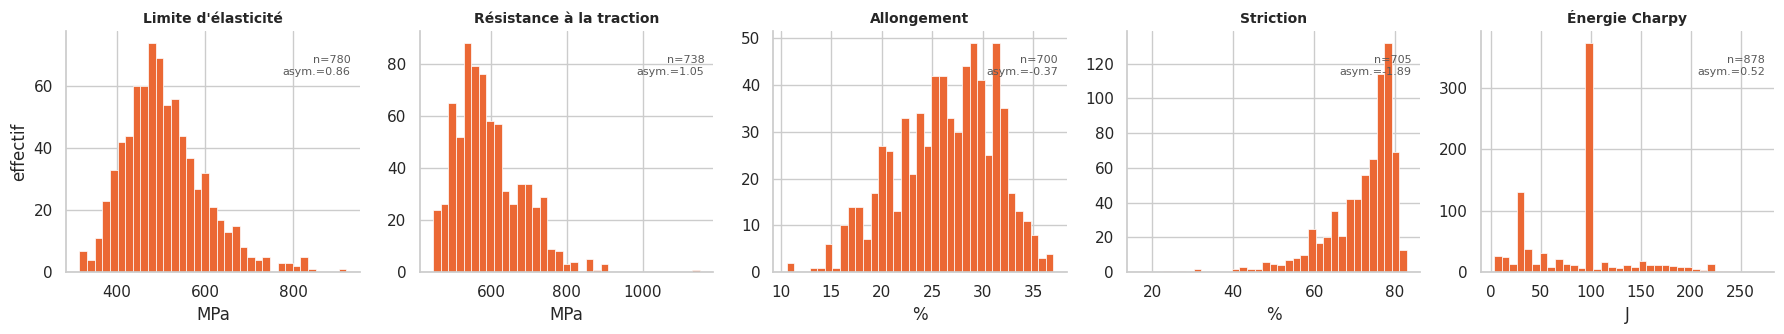

,count,mean,std,min,25%,50%,75%,max
YS,780.0,508.557,92.865,315.0,443.000,495.0,559.25,920.0
UTS,738.0,594.386,88.636,447.0,532.775,575.5,647.00,1151.0
Elong,700.0,26.276,4.896,10.6,22.800,26.8,30.00,37.0
RoA,705.0,71.800,8.927,17.0,68.000,75.0,78.00,83.0
CharpyJ,878.0,87.629,50.113,3.0,38.000,100.0,100.00,270.0
CharpyT,878.0,-34.860,33.935,-114.0,-60.000,-40.0,-18.00,70.0


In [46]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, c in zip(axes, TARGETS):
    s = df[c].dropna()
    ax.hist(s, bins=35, color=C_ORANGE, edgecolor="white", linewidth=0.5)
    ax.set_title(LABELS[c], fontsize=10); ax.set_xlabel(UNITS[c])
    ax.text(0.97, 0.9, f"n={len(s)}\nasym.={s.skew():.2f}", transform=ax.transAxes, ha="right", va="top",
            fontsize=8, color="0.35")
axes[0].set_ylabel("effectif")
plt.tight_layout(); savefig("distrib_cibles"); plt.show()
df[TARGETS + TEST].describe().T

**Constat** : YS, UTS, Elong et RoA ont des distributions régulières (une bosse, quelques valeurs extrêmes plausibles). L'énergie Charpy a un **pic isolé à 100 J** qui ne ressemble pas à une distribution naturelle : il faut comprendre d'où il vient avant de modéliser cette cible.

## 7.2 Le pic à 100 J de l'énergie Charpy

**Étape 1** : quelles valeurs sont sur-représentées, et qui les produit ?

In [47]:
print("Valeurs les plus fréquentes :", df["CharpyJ"].value_counts().head(5).to_dict())
for v in [100, 28]:
    m = df["CharpyJ"] == v
    print(f"{v} J : {m.sum()} lignes, dont {df.loc[m, 'Source'].str.startswith('Ev').mean():.0%} d'Evans")

Valeurs les plus fréquentes : {100.0: 356, 28.0: 118, 50.0: 16, 35.0: 12, 70.0: 12}
100 J : 356 lignes, dont 95% d'Evans
28 J : 118 lignes, dont 99% d'Evans


**Étape 2** : pour ces lignes, qu'est-ce qui varie ? Si l'énergie vaut toujours 100 J, l'information doit être portée par l'**autre** colonne de l'essai, la température :

In [48]:
print("Température d'essai des lignes à 100 J :")
print(df.loc[df["CharpyJ"] == 100, "CharpyT"].describe().round(1).to_dict())

Température d'essai des lignes à 100 J :
{'count': 356.0, 'mean': -40.1, 'std': 26.0, 'min': -85.0, '25%': -58.0, '50%': -45.0, '75%': -28.0, 'max': 59.0}


**Interprétation** : pour ces lignes, la température varie beaucoup (de −85 à +59 °C) alors que l'énergie reste fixe. Evans ne publie pas « l'énergie mesurée à −40 °C » mais **« la température à laquelle l'énergie atteint 100 J »** (et 28 J). C'est une pratique courante : l'énergie Charpy croît avec la température selon une **courbe de transition ductile–fragile**, et on caractérise souvent une soudure par la température où cette courbe franchit un seuil.

**Vérification** : les soudures mesurées à plusieurs températures doivent montrer cette courbe en « S ».

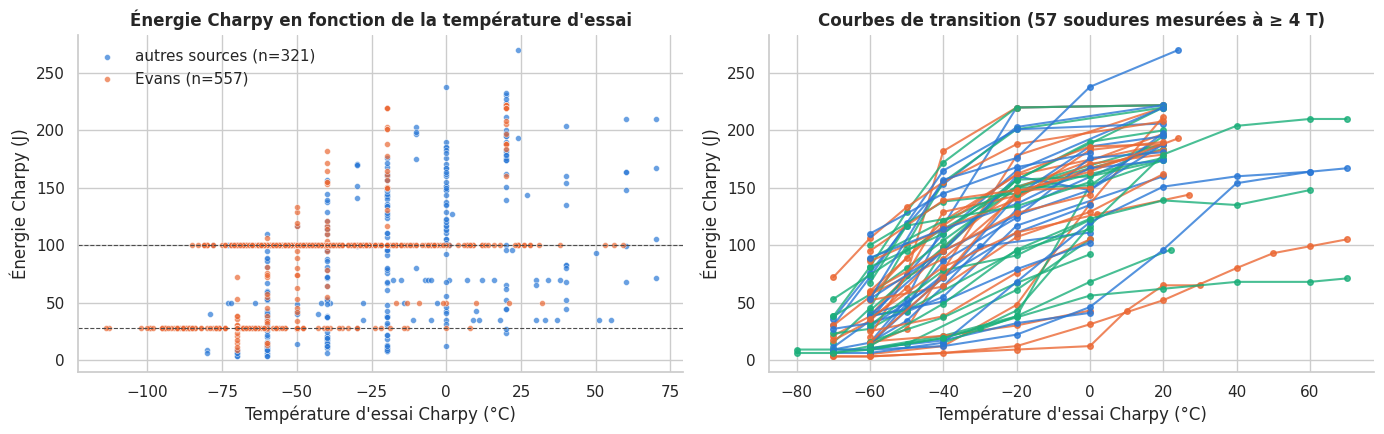

In [49]:
is_ev = df["Source"].str.startswith("Ev")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
m = df["CharpyJ"].notna()
for grp, colr, name in [(~is_ev, C_BLUE, "autres sources"), (is_ev, C_ORANGE, "Evans")]:
    d = df[m & grp]
    axes[0].scatter(d["CharpyT"], d["CharpyJ"], s=18, color=colr, alpha=0.7, label=f"{name} (n={len(d)})",
                    edgecolor="white", linewidth=0.4)
for y in (100, 28): axes[0].axhline(y, color="0.3", lw=0.8, ls="--")
axes[0].set_xlabel(lab("CharpyT")); axes[0].set_ylabel(lab("CharpyJ"))
axes[0].set_title("Énergie Charpy en fonction de la température d'essai"); axes[0].legend(loc="upper left")

multi = df[m].groupby("WeldStateID").filter(lambda g: g["CharpyT"].nunique() >= 4)
for i, (k, g) in enumerate(multi.groupby("WeldStateID")):
    g = g.sort_values("CharpyT")
    axes[1].plot(g["CharpyT"], g["CharpyJ"], "-o", ms=4, lw=1.5, color=PAL3[i % 3], alpha=0.8)
axes[1].set_xlabel(lab("CharpyT")); axes[1].set_ylabel(lab("CharpyJ"))
axes[1].set_title(f"Courbes de transition ({multi['WeldStateID'].nunique()} soudures mesurées à ≥ 4 T)")
plt.tight_layout(); savefig("charpy"); plt.show()

**Confirmation** : à droite, chaque soudure testée à plusieurs températures suit bien une courbe croissante en « S ». À gauche, les lignes d'Evans s'alignent sur les deux droites horizontales 28 J et 100 J.

**Conséquences pour la modélisation** :
+ l'énergie Charpy **n'a de sens qu'avec sa température d'essai** : `CharpyT` doit être une **entrée** du modèle de ténacité ;
+ la physique impose que l'énergie **croisse** avec la température : on pourra l'imposer au modèle (contrainte monotone de `HistGradientBoostingRegressor`) ;
+ autre formulation possible : prédire la température de transition $T_{28J}$ ou $T_{100J}$, ou classer « ≥ 47 J à −40 °C ».

In [50]:
decide("7.2", "Cible Charpy = énergie, avec CharpyT en variable d'entrée (monotonie croissante à tester)",
       "les pics à 100 J / 28 J sont des énergies imposées (Evans publie la température où ce seuil est atteint) ; "
       "l'énergie dépend avant tout de la température d'essai",
       "prédire l'énergie seule sans T (cible incohérente) ; supprimer les lignes d'Evans (≈ 50 % des essais)")

DÉCISION [7.2] Cible Charpy = énergie, avec CharpyT en variable d'entrée (monotonie croissante à tester)
   pourquoi : les pics à 100 J / 28 J sont des énergies imposées (Evans publie la température où ce seuil est atteint) ; l'énergie dépend avant tout de la température d'essai
   alternatives écartées : prédire l'énergie seule sans T (cible incohérente) ; supprimer les lignes d'Evans (≈ 50 % des essais)


## 7.3 Relations entre cibles

**Précaution** : chaque corrélation est calculée sur les lignes où les *deux* cibles sont connues. Entre traction et Charpy, il n'y en a que ~144 (4.6) : ces coefficients-là sont beaucoup moins fiables que les autres.

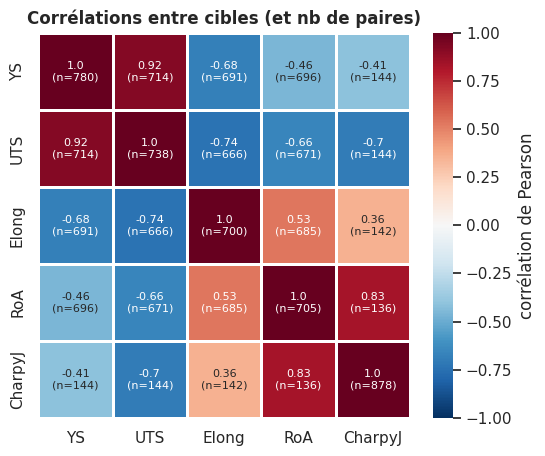

In [51]:
corr_t = df[TARGETS].corr()
fig, ax = plt.subplots(figsize=(6, 5))
annot = corr_t.round(2).astype(str) + "\n(n=" + cooc.astype(str) + ")"
sns.heatmap(corr_t, annot=annot, fmt="", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, linewidths=2,
            linecolor="white", annot_kws={"size": 8}, cbar_kws={"label": "corrélation de Pearson"})
ax.set_title("Corrélations entre cibles (et nb de paires)")
savefig("cibles_correlations"); plt.show()

Pour relier traction et ténacité avec plus de données, on utilise le regroupement par état métallurgique (5.3) : on associe à chaque essai Charpy la résistance mesurée sur **la même soudure dans le même état**.

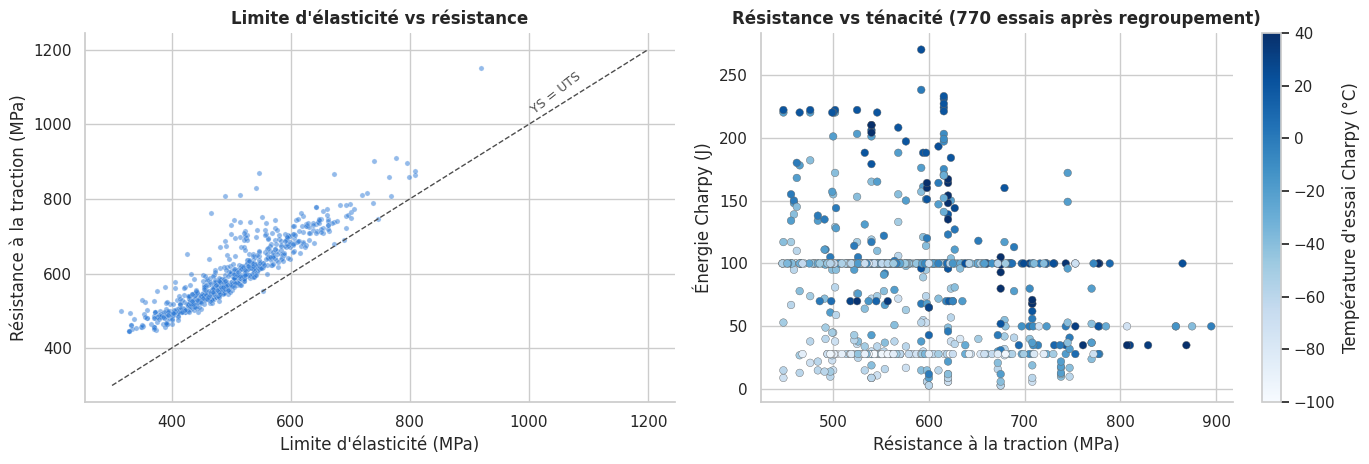

Rapport YS/UTS : médiane 0.85
Spearman UTS–Charpy sur les essais regroupés : -0.18


In [52]:
state = df.groupby("WeldStateID").agg(YS=("YS", "mean"), UTS=("UTS", "mean"))
chp = df.dropna(subset=["CharpyJ"])[["WeldStateID", "CharpyT", "CharpyJ"]].join(state, on="WeldStateID")
chp = chp.dropna(subset=["UTS"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].scatter(df["YS"], df["UTS"], s=14, color=C_BLUE, alpha=0.5, edgecolor="white", linewidth=0.3)
axes[0].plot([300, 1200], [300, 1200], color="0.3", lw=1, ls="--")
axes[0].text(1000, 1030, "YS = UTS", fontsize=9, color="0.3", rotation=38)
axes[0].set_xlabel(lab("YS")); axes[0].set_ylabel(lab("UTS")); axes[0].set_title("Limite d'élasticité vs résistance")

sc = axes[1].scatter(chp["UTS"], chp["CharpyJ"], c=chp["CharpyT"], cmap="Blues", s=30, edgecolor="0.4",
                     linewidth=0.3, vmin=-100, vmax=40)
plt.colorbar(sc, ax=axes[1], label=lab("CharpyT"))
axes[1].set_xlabel(lab("UTS")); axes[1].set_ylabel(lab("CharpyJ"))
axes[1].set_title(f"Résistance vs ténacité ({len(chp)} essais après regroupement)")
plt.tight_layout(); savefig("compromis_resistance_tenacite"); plt.show()

print("Rapport YS/UTS : médiane", round((df.YS / df.UTS).median(), 2))
print("Spearman UTS–Charpy sur les essais regroupés :", round(chp[["UTS", "CharpyJ"]].corr(method="spearman").iloc[0, 1], 2))

**Lecture** :
+ **YS et UTS sont très liés** (r ≈ 0,92, YS ≈ 0,85 × UTS) : ils portent en grande partie la même information. On pourra exploiter cette redondance (régression multi-sorties).
+ **Résistance et ductilité s'opposent** (UTS–Elong ≈ −0,74, sur ~670 paires : fiable).
+ **Résistance et ténacité** : la matrice indique r = −0,70, mais sur seulement 144 paires. Sur les ~770 essais obtenus après regroupement, la corrélation de Spearman n'est plus que d'environ −0,2. **Le premier chiffre était trompeur** : les 144 lignes forment une sous-population particulière. De plus, le graphique de droite montre que l'énergie dépend fortement de la température d'essai (la couleur), ce qui brouille toute corrélation brute. Le compromis résistance/ténacité n'est donc **pas établi** à ce stade : il faudra le tester à température d'essai égale, avec un modèle qui a `CharpyT` en entrée.

Au moins pour la ductilité, une « bonne » soudure est donc un **compromis** et non le maximum d'une seule propriété. C'est ce qui guidera les recommandations finales.

## 7.4 Effet du traitement thermique

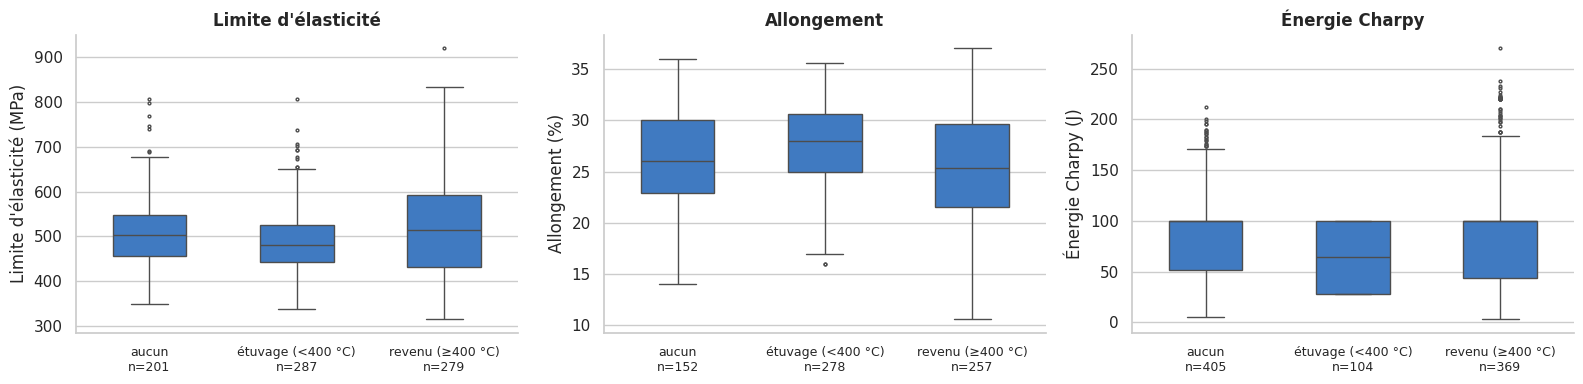

Part des soudures revenues parmi celles à Cr > 1 %m : 83%


In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ordc = ["aucun", "étuvage (<400 °C)", "revenu (≥400 °C)"]
for ax, c in zip(axes, ["YS", "Elong", "CharpyJ"]):
    sns.boxplot(data=df, x="PWHT_class", y=c, order=ordc, ax=ax, color=C_BLUE, width=0.5, fliersize=2)
    n = df.dropna(subset=[c])["PWHT_class"].value_counts()
    ax.set_xticks(range(len(ordc))); ax.set_xticklabels([f"{o}\nn={n.get(o, 0)}" for o in ordc], fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel(lab(c)); ax.set_title(LABELS[c])
plt.tight_layout(); savefig("effet_pwht"); plt.show()
print("Part des soudures revenues parmi celles à Cr > 1 %m :",
      f"{(df.loc[df['Cr'] > 1, 'PWHT_class'] == 'revenu (≥400 °C)').mean():.0%}")

**Piège d'interprétation** : on serait tenté de lire « le revenu augmente la dispersion de la résistance ». Mais les aciers Cr-Mo (les plus résistants) sont **presque toujours** revenus (cf. la proportion affichée) : l'effet du traitement et celui de la composition sont **confondus**. Une comparaison de boîtes à moustaches ne permet pas de les séparer ; il faut une analyse multivariée (ACP, puis modèles).

# 8. Liens entre entrées et cibles

## 8.1 Quel coefficient de corrélation ?

**Question** : Pearson mesure une relation **linéaire** et est sensible aux valeurs extrêmes ; Spearman (corrélation des rangs) mesure une relation **monotone** quelconque. Nos entrées sont très asymétriques (6.1) : les deux peuvent différer. Exemple avec Cr et YS :

In [54]:
pe = df[["Cr", "YS"]].corr().iloc[0, 1]
sp_ = df[["Cr", "YS"]].corr(method="spearman").iloc[0, 1]
print(f"Cr – YS : Pearson = {pe:.2f} | Spearman = {sp_:.2f}")

Cr – YS : Pearson = 0.40 | Spearman = 0.50


La relation est monotone mais pas linéaire (forte hausse entre 0 et ~2 % de Cr, puis plateau) : Pearson la sous-estime. **On utilise Spearman.** Deux précautions à garder en tête :
+ chaque coefficient est calculé sur les paires disponibles, donc sur des **sous-populations différentes** ;
+ une corrélation marginale ne dit rien des **effets combinés** ni de la causalité (voir le piège de 7.4).

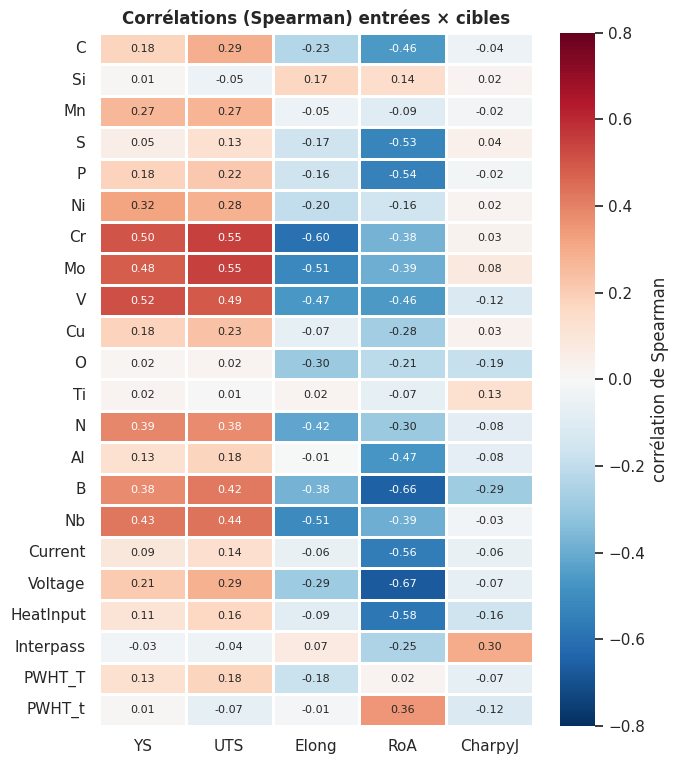

Spearman(CharpyT, CharpyJ) = 0.46


In [55]:
IN_CORR = [c for c in IN_NUM if df[c].notna().mean() > 0.2]
sp = df[IN_CORR + TARGETS].corr(method="spearman").loc[IN_CORR, TARGETS]
fig, ax = plt.subplots(figsize=(7, 9))
sns.heatmap(sp, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-0.8, vmax=0.8, ax=ax, linewidths=1,
            linecolor="white", annot_kws={"size": 8}, cbar_kws={"label": "corrélation de Spearman"})
ax.set_title("Corrélations (Spearman) entrées × cibles")
savefig("spearman_entrees_cibles"); plt.show()
print("Spearman(CharpyT, CharpyJ) = %.2f" % df[["CharpyT", "CharpyJ"]].corr(method="spearman").iloc[0, 1])

**Lecture** (en gardant les précautions ci-dessus) :
+ **YS, UTS** : augmentent avec les éléments d'alliage Cr, Mo, V, Nb, N, Ni, Mn. C'est cohérent avec la métallurgie (durcissement par solution solide et par précipitation).
+ **Elong** : les mêmes variables, avec le signe opposé. C'est le compromis résistance/ductilité vu en 7.3.
+ **RoA** : surtout liée au **procédé** (courant, tension, énergie : ρ ≈ −0,6) et aux impuretés (S, P).
+ **Charpy** : presque aucune corrélation forte avec la composition, mais ρ ≈ 0,46 avec la température d'essai. C'est attendu : l'effet de la température masque les autres, qui ne pourront apparaître qu'**à température égale**, donc dans un modèle multivarié.

→ Les relations sont non linéaires et multivariées : on s'attend à ce que les modèles linéaires soient insuffisants, surtout pour Charpy.

## 8.2 Quelques relations bivariées

On superpose au nuage la **médiane par classe** (déciles de $x$) : elle résume la tendance sans supposer de forme, et elle est robuste aux valeurs extrêmes.

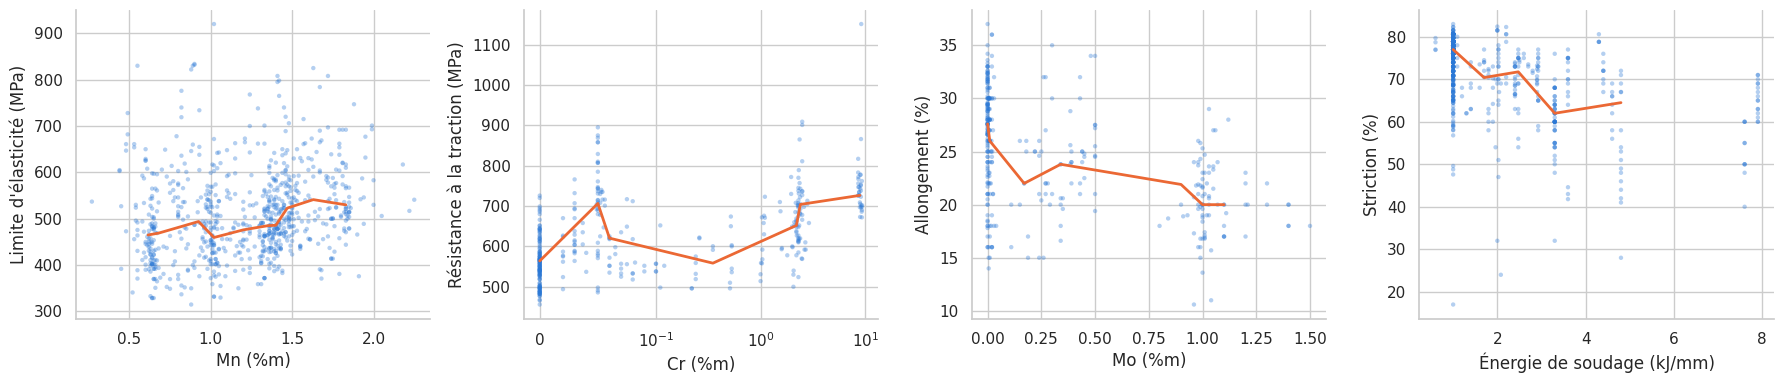

In [56]:
def binned_median(ax, x, y, bins=10, color="black"):
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    d["b"] = pd.qcut(d["x"], q=bins, duplicates="drop")
    g = d.groupby("b", observed=True).agg(x=("x", "median"), y=("y", "median"))
    ax.plot(g["x"], g["y"], color=color, lw=2)

pairs = [("Mn", "YS"), ("Cr", "UTS"), ("Mo", "Elong"), ("HeatInput", "RoA")]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df[x], df[y], s=10, color=C_BLUE, alpha=0.35, edgecolor="none")
    binned_median(ax, df[x], df[y], color=C_ORANGE)
    ax.set_xlabel(lab(x)); ax.set_ylabel(lab(y))
    if x == "Cr": ax.set_xscale("symlog", linthresh=0.1)
plt.tight_layout(); savefig("relations_bivariees"); plt.show()

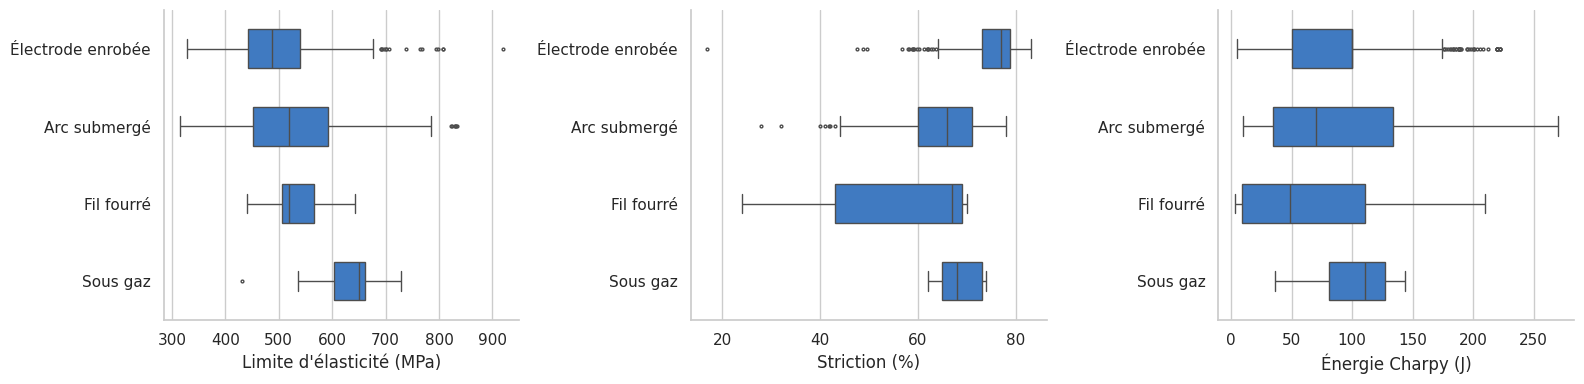

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, ["YS", "RoA", "CharpyJ"]):
    sns.boxplot(data=df, y="WeldGroup", x=c, order=order_g, ax=ax, color=C_BLUE, width=0.5, fliersize=2)
    ax.set_xlabel(lab(c)); ax.set_ylabel("")
plt.tight_layout(); savefig("cibles_par_procede"); plt.show()

# 9. Analyse en composantes principales (ACP)

## 9.1 Pourquoi, et sur quoi ?

**Objectif** (cf. CM/TD Réduction de dimension) : résumer les 22 variables d'entrée numériques en quelques axes pour (i) visualiser la base, (ii) comprendre quelles variables varient ensemble, (iii) savoir si une réduction de dimension serait utile avant la modélisation.

**Choix des données** :
+ **entrées uniquement**, pas les cibles : on veut décrire l'espace des soudures possibles, et les cibles sont trop souvent manquantes ;
+ **toutes les lignes**, y compris sans cible : l'ACP est non supervisée, autant utiliser toute l'information sur $X$ ;
+ **variables numériques seulement** : les variables catégorielles (procédé, classe de traitement) serviront à **colorer** les projections. Cela permet de vérifier *a posteriori* si la structure trouvée correspond au procédé, sans l'avoir imposée.

**Imputation** : l'ACP n'accepte pas de valeurs manquantes, et on a vu que garder les lignes complètes est impossible (4.5). On impute par la **médiane**, et le courant et la tension par la médiane **de leur type de soudage** (ils dépendent fortement du procédé, 6.2).

<div class="alert alert-block alert-warning">

**Limite de ce choix** : imputer par la médiane crée un pic artificiel et réduit la variance des colonnes très manquantes, donc leur poids dans l'ACP. On vérifiera en 9.6 que les conclusions ne dépendent pas trop de ce choix.

</div>

In [58]:
PCA_VARS = IN_NUM
def impute_for_pca(data, strategy="median"):
    X = data[PCA_VARS].copy()
    for c in ["Current", "Voltage"]:
        X[c] = X[c].fillna(data.groupby("WeldType")[c].transform("median"))
    if strategy == "median":
        return X.fillna(X.median())
    if strategy == "zero_alloy":          # éléments d'alliage manquants = 0 (hypothèse 'non ajouté'), le reste = médiane
        alloy = ["Ni", "Cr", "Mo", "V", "Cu", "Ti", "Al", "B", "Nb"]
        X[alloy] = X[alloy].fillna(0)
        return X.fillna(X.median())

Xp = impute_for_pca(df)
print("Dimensions :", Xp.shape, "| manquants restants :", Xp.isna().sum().sum())

Dimensions : (1652, 22) | manquants restants : 0


## 9.2 Faut-il standardiser ? Démonstration

In [59]:
pca_raw = PCA().fit(Xp)
pca_std = PCA().fit(StandardScaler().fit_transform(Xp))
w = pd.Series(np.abs(pca_raw.components_[0]), PCA_VARS)
print(f"Sans standardisation : CP1 = {100 * pca_raw.explained_variance_ratio_[0]:.0f} % de la variance, "
      f"dominée par {w.idxmax()} (poids {w.max():.2f})")
print(f"Avec standardisation : CP1 = {100 * pca_std.explained_variance_ratio_[0]:.0f} % de la variance")

Sans standardisation : CP1 = 47 % de la variance, dominée par PWHT_T (poids 0.94)
Avec standardisation : CP1 = 20 % de la variance


Sans standardisation, la première composante est **presque entièrement une seule variable** : la température de traitement thermique, simplement parce que ses valeurs (0 à 760 °C) varient bien plus en nombre absolu que des teneurs de quelques centièmes de %. Le résultat dépendrait donc des **unités** choisies, ce qui n'a pas de sens physique. **On standardise** (centrer-réduire) : chaque variable a alors le même poids a priori.

## 9.3 Combien de composantes ?

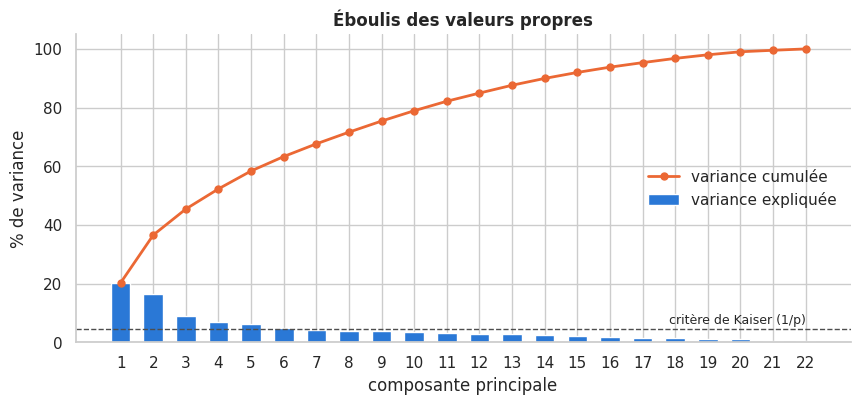

Kaiser (valeur propre > 1) : 6 composantes
70 % de variance cumulée   : 8 composantes
Premier plan (CP1+CP2)     : 37 %


In [60]:
Xs = StandardScaler().fit_transform(Xp)
pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_
k = np.arange(1, len(evr) + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(k, 100 * evr, color=C_BLUE, width=0.6, label="variance expliquée")
ax.plot(k, 100 * np.cumsum(evr), "-o", color=C_ORANGE, ms=5, lw=2, label="variance cumulée")
ax.axhline(100 / len(evr), color="0.3", ls="--", lw=1)
ax.text(len(evr), 100 / len(evr) + 2, "critère de Kaiser (1/p)", ha="right", fontsize=9)
ax.set_xlabel("composante principale"); ax.set_ylabel("% de variance"); ax.set_xticks(k)
ax.set_title("Éboulis des valeurs propres"); ax.legend(loc="center right")
savefig("acp_eboulis"); plt.show()

n70 = int(np.argmax(np.cumsum(evr) >= 0.70) + 1)
print(f"Kaiser (valeur propre > 1) : {(pca.explained_variance_ > 1).sum()} composantes")
print(f"70 % de variance cumulée   : {n70} composantes")
print(f"Premier plan (CP1+CP2)     : {100 * evr[:2].sum():.0f} %")

**Constat** : les critères usuels **ne sont pas d'accord** : le coude de l'éboulis est vers 2–3 composantes, le critère de Kaiser en donne 6, et il en faut 8 pour 70 % de la variance.

**Interprétation** : la variance est **étalée** sur de nombreuses directions. Il n'existe pas de petit sous-espace qui résume bien les soudures, ce qui est logique pour une base compilée à partir d'études qui font chacune varier des éléments différents.

**Décision** : le nombre de composantes dépend de l'usage :
+ pour **interpréter**, on regarde les 4 premières ;
+ pour le **clustering** (section 10), on garde 8 composantes (≈ 2/3 de la variance), compromis entre bruit et information ;
+ pour la **modélisation**, on ne réduira pas la dimension a priori ; si on le teste, le nombre de composantes sera choisi par validation croisée.

In [61]:
decide("9.3", "Standardisation avant ACP ; ACP utilisée pour l'interprétation, pas comme pré-traitement imposé",
       "sans standardisation CP1 = une seule variable (artefact d'unité) ; variance diffuse (critères discordants : 2 à 8 CP)",
       "réduire à 2-3 composantes avant modélisation (perte d'information importante)")

DÉCISION [9.3] Standardisation avant ACP ; ACP utilisée pour l'interprétation, pas comme pré-traitement imposé
   pourquoi : sans standardisation CP1 = une seule variable (artefact d'unité) ; variance diffuse (critères discordants : 2 à 8 CP)
   alternatives écartées : réduire à 2-3 composantes avant modélisation (perte d'information importante)


## 9.4 Que représentent les axes ? Cercle des corrélations

Chaque flèche représente la **corrélation** d'une variable avec les deux axes. Une flèche proche du cercle est bien représentée par le plan ; des flèches proches les unes des autres indiquent des variables corrélées.

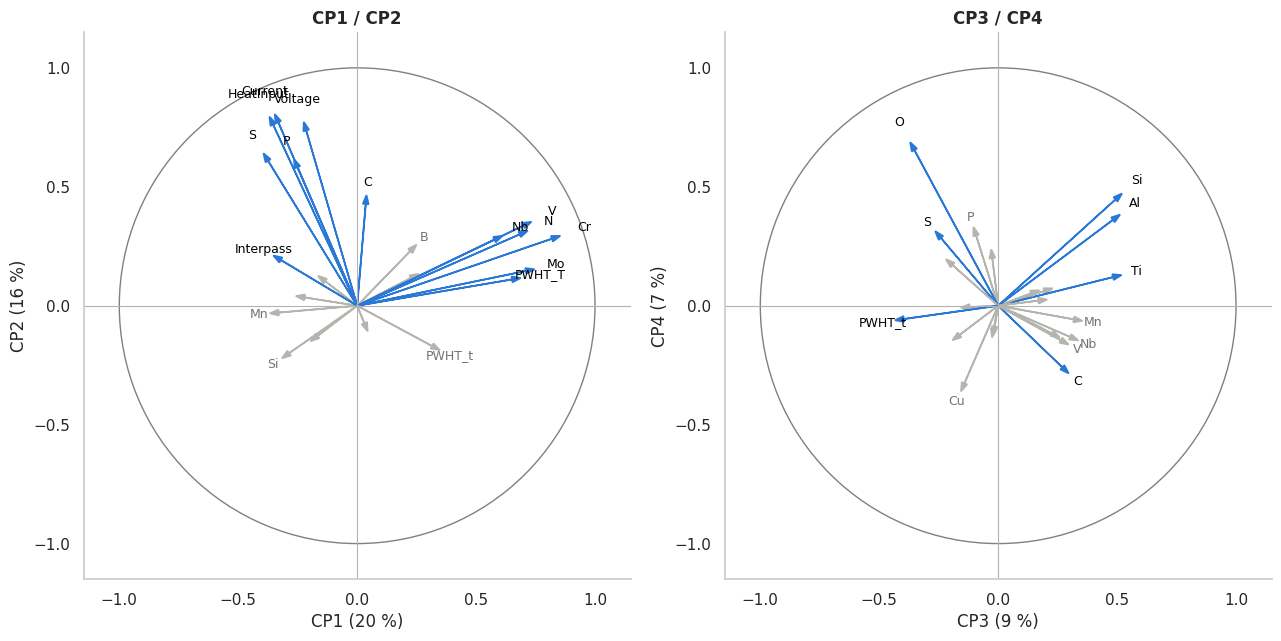

,CP1,CP2,CP3,CP4
Cr,0.85,0.29,0.23,0.07
Mo,0.75,0.15,-0.03,0.24
V,0.73,0.35,0.30,-0.16
N,0.72,0.32,0.17,0.07
PWHT_T,0.69,0.12,-0.22,0.20
Nb,0.61,0.29,0.34,-0.15
S,-0.39,0.64,-0.26,0.31
Mn,-0.37,-0.03,0.35,-0.06
HeatInput,-0.37,0.80,-0.03,-0.13
Current,-0.35,0.81,-0.02,-0.12


In [62]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

def correlation_circle(ax, i, j):
    ax.add_patch(plt.Circle((0, 0), 1, fill=False, color="0.5", lw=1))
    ax.axhline(0, color="0.7", lw=0.8); ax.axvline(0, color="0.7", lw=0.8)
    for v, (a, b) in zip(PCA_VARS, loadings[:, [i, j]]):
        r = np.hypot(a, b)
        ax.arrow(0, 0, a, b, color=C_BLUE if r > 0.4 else C_GREY, head_width=0.025,
                 length_includes_head=True, lw=1.2)
        if r > 0.3:
            ax.text(a * 1.12, b * 1.12, v, ha="center", va="center", fontsize=9,
                    color="black" if r > 0.4 else "0.45")
    ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15); ax.set_aspect("equal"); ax.grid(False)
    ax.set_xlabel(f"CP{i+1} ({100*evr[i]:.0f} %)"); ax.set_ylabel(f"CP{j+1} ({100*evr[j]:.0f} %)")

fig, axes = plt.subplots(1, 2, figsize=(13, 6.3))
correlation_circle(axes[0], 0, 1); axes[0].set_title("CP1 / CP2")
correlation_circle(axes[1], 2, 3); axes[1].set_title("CP3 / CP4")
plt.tight_layout(); savefig("acp_cercle"); plt.show()

pd.DataFrame(loadings[:, :4], index=PCA_VARS, columns=["CP1", "CP2", "CP3", "CP4"]).round(2) \
  .sort_values("CP1", key=np.abs, ascending=False).head(10)

**Interprétation des axes** (on cite les variables de plus forte corrélation) :
+ **CP1** : Cr, Mo, V, N, Nb et la température de revenu varient ensemble (corrélations 0,6–0,85). C'est un axe de **« degré d'alliage »** : il oppose les aciers C-Mn aux aciers Cr-Mo, presque toujours revenus (cf. 7.4). De l'autre côté on trouve Mn, S et l'énergie de soudage, typiques des soudures C-Mn, en particulier à l'arc submergé.
+ **CP2** : courant et énergie de soudage (≈ 0,8), puis S (0,64). C'est un axe de **« procédé »** : il oppose l'électrode enrobée (faible énergie) à l'arc submergé (forte énergie ; le flux apporte aussi du soufre).
+ **CP3/CP4** : les corrélations sont plus modestes (≤ 0,7). On devine une opposition entre les **désoxydants** (Si, Al, Ti, sur CP3) et l'**oxygène** (sur CP4), ce qui aurait un sens métallurgique : ces éléments se combinent à l'oxygène pour former les inclusions sur lesquelles germe la ferrite aciculaire. Mais avec des corrélations aussi faibles, cela reste une **hypothèse**, pas une conclusion.

Ce ne sont que des **interprétations** : on les vérifie en colorant la projection par les variables catégorielles, qui n'ont pas servi à construire l'ACP.

## 9.5 Projection des soudures

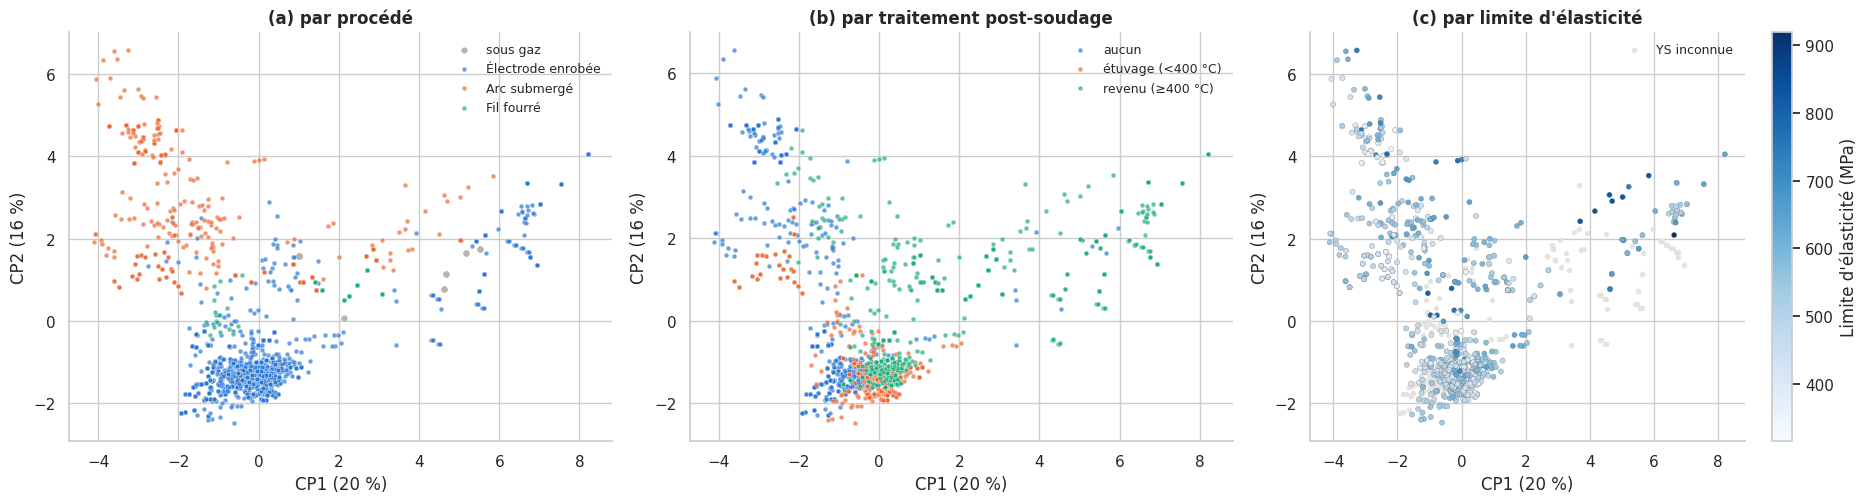

In [63]:
Z = pca.transform(Xs)
df["PC1"], df["PC2"] = Z[:, 0], Z[:, 1]
fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))

main = ["Électrode enrobée", "Arc submergé", "Fil fourré"]
other = ~df["WeldGroup"].isin(main)
axes[0].scatter(df.loc[other, "PC1"], df.loc[other, "PC2"], s=12, color=C_GREY, label="sous gaz")
for g_, colr in zip(main, PAL3):
    d = df[df["WeldGroup"] == g_]
    axes[0].scatter(d["PC1"], d["PC2"], s=12, color=colr, alpha=0.7, label=g_, edgecolor="white", linewidth=0.3)
axes[0].set_title("(a) par procédé"); axes[0].legend(fontsize=9, loc="upper right")

for g_, colr in zip(ordc, PAL3):
    d = df[df["PWHT_class"] == g_]
    axes[1].scatter(d["PC1"], d["PC2"], s=12, color=colr, alpha=0.7, label=g_, edgecolor="white", linewidth=0.3)
axes[1].set_title("(b) par traitement post-soudage"); axes[1].legend(fontsize=9, loc="upper right")

nolab = df["YS"].isna()
axes[2].scatter(df.loc[nolab, "PC1"], df.loc[nolab, "PC2"], s=8, color="#e4e3df", label="YS inconnue")
sc = axes[2].scatter(df.loc[~nolab, "PC1"], df.loc[~nolab, "PC2"], c=df.loc[~nolab, "YS"], cmap="Blues",
                     s=14, edgecolor="0.4", linewidth=0.2)
plt.colorbar(sc, ax=axes[2], label=lab("YS"))
axes[2].set_title("(c) par limite d'élasticité"); axes[2].legend(fontsize=9, loc="upper right")
for ax in axes:
    ax.set_xlabel(f"CP1 ({100*evr[0]:.0f} %)"); ax.set_ylabel(f"CP2 ({100*evr[1]:.0f} %)")
plt.tight_layout(); savefig("acp_projections"); plt.show()

**Vérification des interprétations** :
+ (a) l'arc submergé se détache bien vers les **CP2 élevées** : l'interprétation « procédé » de CP2 est confirmée ;
+ (b) les soudures revenues s'étalent vers les **CP1 élevées** : l'interprétation « degré d'alliage » de CP1 est confirmée ;
+ (c) la limite d'élasticité augmente le long de CP1 : **le degré d'alliage est le premier facteur de résistance**. En revanche, dans le gros nuage C-Mn, la couleur varie sans structure visible dans ce plan : prédire la résistance de ces soudures demandera plus que deux composantes.
+ les points gris (YS inconnue) couvrent **la même région** que les points étiquetés. C'est une condition favorable au **semi-supervisé** : les lignes non étiquetées renseignent sur la même distribution de $X$.

## 9.6 Les conclusions dépendent-elles de l'imputation ?

On refait l'ACP avec une autre hypothèse d'imputation : éléments d'alliage manquants = 0 (« non ajouté », section 4.4). Si les interprétations tiennent, les axes doivent rester semblables.

In [64]:
Xs0 = StandardScaler().fit_transform(impute_for_pca(df, "zero_alloy"))
pca0 = PCA().fit(Xs0)
Z0 = pca0.transform(Xs0)
for i in range(2):
    r = abs(np.corrcoef(Z[:, i], Z0[:, i])[0, 1])
    print(f"CP{i+1} : |corrélation| entre scores (médiane vs zéro) = {r:.2f} | "
          f"variance {100*evr[i]:.0f} % vs {100*pca0.explained_variance_ratio_[i]:.0f} %")
l0 = pca0.components_.T * np.sqrt(pca0.explained_variance_)
pd.DataFrame({"CP1 médiane": loadings[:, 0], "CP1 zéro": l0[:, 0] * np.sign(np.dot(loadings[:, 0], l0[:, 0])),
              "CP2 médiane": loadings[:, 1], "CP2 zéro": l0[:, 1] * np.sign(np.dot(loadings[:, 1], l0[:, 1]))},
             index=PCA_VARS).round(2).sort_values("CP1 médiane", key=np.abs, ascending=False).head(8)

CP1 : |corrélation| entre scores (médiane vs zéro) = 0.95 | variance 20 % vs 20 %
CP2 : |corrélation| entre scores (médiane vs zéro) = 0.95 | variance 16 % vs 17 %


,CP1 médiane,CP1 zéro,CP2 médiane,CP2 zéro
Cr,0.85,0.90,0.29,0.05
Mo,0.75,0.80,0.15,0.21
V,0.73,0.79,0.35,0.11
N,0.72,0.77,0.32,0.07
PWHT_T,0.69,0.71,0.12,-0.08
Nb,0.61,0.65,0.29,0.07
S,-0.39,-0.17,0.64,0.74
Mn,-0.37,-0.39,-0.03,0.06


**Constat** : les scores sur CP1 et CP2 sont corrélés à 0,95 d'une imputation à l'autre, et les variables dominantes (Cr, Mo, V, N pour CP1 ; énergie et S pour CP2) sont les mêmes. L'interprétation « degré d'alliage / procédé » est donc **robuste** au choix d'imputation. En revanche, les contributions *secondaires* de CP2 changent (Cr, V, N passent de ≈ 0,3 à ≈ 0,1) : elles dépendent de l'imputation et il ne faut pas les sur-interpréter. C'est un argument de plus pour choisir l'imputation **par validation croisée** plutôt que d'en figer une.

# 10. Clustering : existe-t-il des familles de soudures ?

**Objectif** : l'ACP suggère plusieurs populations (C-Mn / Cr-Mo, électrode / arc submergé). Un clustering (TD k-means et CAH) permet de les délimiter objectivement, pour ensuite les **décrire** et éventuellement **stratifier** la validation croisée.

**Sur quelles données ?** Sur les **8 premières composantes** plutôt que sur les 22 variables standardisées : cela écarte les directions de faible variance, qui portent surtout du bruit et les artefacts d'imputation, tout en gardant ≈ 2/3 de la variance (9.3).

## 10.1 Nombre de clusters

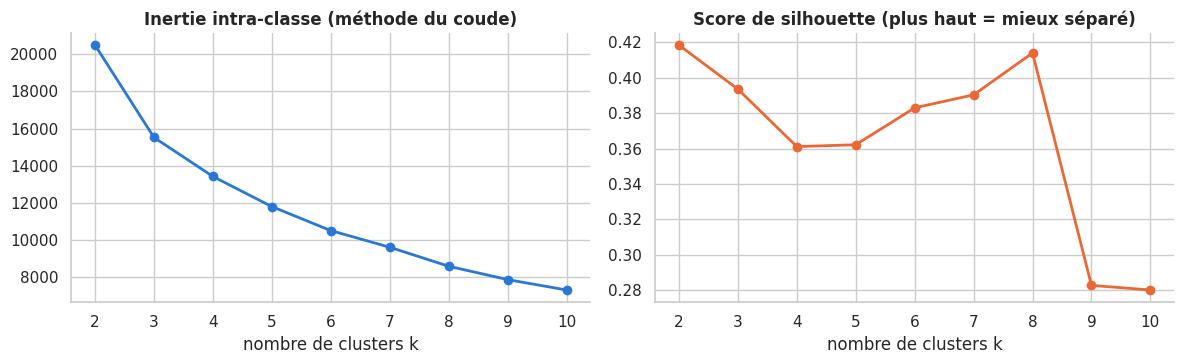

Silhouette : {2: np.float64(0.418), 3: np.float64(0.394), 4: np.float64(0.361), 5: np.float64(0.362), 6: np.float64(0.383), 7: np.float64(0.39), 8: np.float64(0.414), 9: np.float64(0.283), 10: np.float64(0.28)}


In [65]:
Z8 = Z[:, :8]
ks = range(2, 11)
inertia, sil = [], []
for kk in ks:
    km = KMeans(n_clusters=kk, n_init=20, random_state=0).fit(Z8)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Z8, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(list(ks), inertia, "-o", color=C_BLUE, lw=2); axes[0].set_title("Inertie intra-classe (méthode du coude)")
axes[1].plot(list(ks), sil, "-o", color=C_ORANGE, lw=2); axes[1].set_title("Score de silhouette (plus haut = mieux séparé)")
for ax in axes: ax.set_xlabel("nombre de clusters k")
plt.tight_layout(); savefig("kmeans_choix_k"); plt.show()
print("Silhouette :", dict(zip(ks, np.round(sil, 3))))

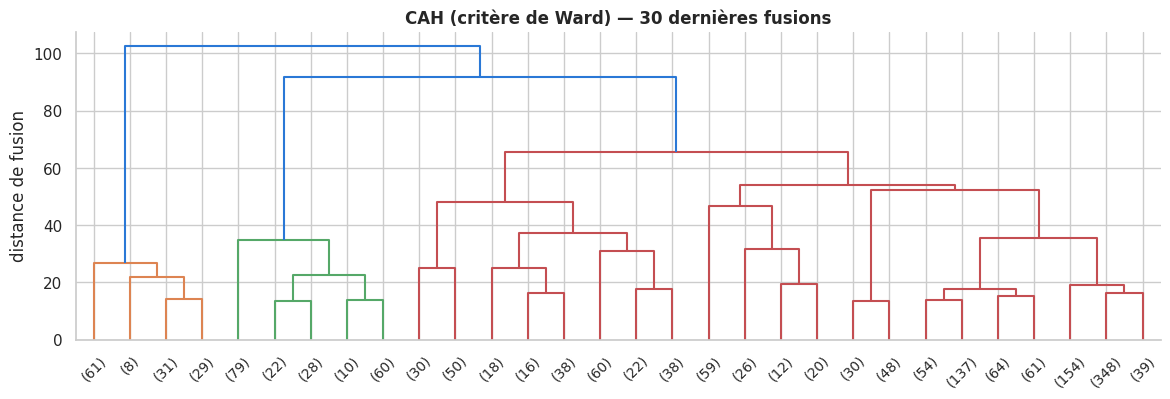

In [66]:
Lk = linkage(Z8, method="ward")
fig, ax = plt.subplots(figsize=(14, 4))
dendrogram(Lk, truncate_mode="lastp", p=30, ax=ax, color_threshold=None, above_threshold_color=C_BLUE)
ax.set_title("CAH (critère de Ward) — 30 dernières fusions"); ax.set_ylabel("distance de fusion")
savefig("cah_dendrogramme"); plt.show()

**Constat** : le coude est peu marqué et la silhouette varie peu. Aucun $k$ ne s'impose nettement, ce qui est cohérent avec la variance diffuse de l'ACP : les soudures forment un **continuum** plus que des amas bien séparés.

**Décision** : on choisit $k$ selon deux critères complémentaires :
1. **l'interprétabilité** : un petit nombre de familles qu'on peut nommer métallurgiquement ;
2. la **stabilité** : un bon clustering ne doit pas changer si l'on relance k-means avec une autre initialisation, ni si l'on utilise une autre méthode (CAH). On mesure l'accord entre deux partitions par l'**indice de Rand ajusté** (ARI : 1 = partitions identiques, 0 = accord dû au hasard).

In [67]:
def stability(kk, seeds=range(5)):
    labs = [KMeans(n_clusters=kk, n_init=10, random_state=s).fit_predict(Z8) for s in seeds]
    ari_seeds = np.mean([adjusted_rand_score(labs[0], l) for l in labs[1:]])
    ari_cah = adjusted_rand_score(labs[0], fcluster(Lk, kk, "maxclust"))
    return ari_seeds, ari_cah

stab = pd.DataFrame([(kk, *stability(kk)) for kk in range(2, 8)],
                    columns=["k", "ARI moyen entre initialisations", "ARI k-means vs CAH"]).set_index("k").round(2)
stab["silhouette"] = np.round(sil[:6], 3)
stab

,ARI moyen entre initialisations,ARI k-means vs CAH,silhouette
k,,,
2,1.00,0.87,0.418
3,1.00,0.76,0.394
4,0.88,0.85,0.361
5,1.00,0.66,0.362
6,0.98,0.82,0.383
7,0.96,0.82,0.390


**Lecture du tableau** : $k = 2$ a la meilleure silhouette et une stabilité parfaite, mais deux groupes seulement ne suffisent pas à décrire la base : on sait déjà (6.1, 9.5) qu'elle contient au moins des aciers C-Mn soudés de deux façons et deux nuances Cr-Mo. $k = 4$ a une silhouette un peu plus faible (0,36 contre 0,42), mais reste **stable** (ARI ≈ 0,85–0,9 entre initialisations et avec la CAH).

**Décision** : $k = 4$. On accepte une séparation un peu moins nette en échange de groupes **interprétables** ; c'est légitime ici car le clustering sert à *décrire*, pas à prédire. On vérifie ci-dessous que les groupes ont bien un sens.

In [68]:
K = 4
km = KMeans(n_clusters=K, n_init=50, random_state=0).fit(Z8)
df["cluster"] = km.labels_

prof = df.groupby("cluster").agg(
    n=("C", "size"),
    **{c: (c, "median") for c in ["C", "Mn", "Ni", "Cr", "Mo", "O", "HeatInput", "PWHT_T"]},
    **{f"{t} moy.": (t, "mean") for t in ["YS", "UTS", "Elong", "CharpyJ"]},
)
prof["procédé majoritaire"] = df.groupby("cluster")["WeldGroup"].agg(lambda s: s.value_counts().index[0])
prof["nb sources"] = df.groupby("cluster")["Source"].nunique()
prof.round(2)

,n,C,Mn,Ni,Cr,Mo,O,HeatInput,PWHT_T,YS moy.,UTS moy.,Elong moy.,CharpyJ moy.,procédé majoritaire,nb sources
cluster,,,,,,,,,,,,,,,
0,1047,0.07,1.36,0.00,0.00,0.00,422.0,1.0,250.0,492.83,571.77,27.41,91.95,Électrode enrobée,13
1,211,0.07,0.88,0.17,2.30,1.04,556.0,2.0,690.0,542.21,647.07,21.50,87.38,Arc submergé,14
2,122,0.09,1.01,0.17,8.90,1.00,490.0,1.1,750.0,640.10,748.73,19.64,51.67,Électrode enrobée,5
3,272,0.09,1.38,0.06,0.04,0.02,410.0,3.6,0.0,508.84,604.28,26.43,71.31,Arc submergé,11


In [69]:
pd.crosstab(df["cluster"], df["WeldGroup"])

WeldGroup,Arc submergé,Fil fourré,Sous gaz,Électrode enrobée
cluster,,,,
0,0,11,0,1036
1,93,75,7,36
2,15,0,8,99
3,262,1,0,9


In [70]:
decide("10", f"Clustering k-means (k={K}) sur 8 CP, choisi pour sa stabilité et son interprétabilité ; "
             "usage descriptif / stratification",
       "aucun k n'est imposé par les critères internes (continuum) ; k=4 stable (ARI ≈ 0,85-0,9) et interprétable "
       "(C-Mn électrode / C-Mn arc submergé / 2¼Cr-1Mo / 9Cr-1Mo)",
       "k=2 (meilleure silhouette mais trop grossier)")

DÉCISION [10] Clustering k-means (k=4) sur 8 CP, choisi pour sa stabilité et son interprétabilité ; usage descriptif / stratification
   pourquoi : aucun k n'est imposé par les critères internes (continuum) ; k=4 stable (ARI ≈ 0,85-0,9) et interprétable (C-Mn électrode / C-Mn arc submergé / 2¼Cr-1Mo / 9Cr-1Mo)
   alternatives écartées : k=2 (meilleure silhouette mais trop grossier)


<div class="alert alert-block alert-success">

**Interprétation des clusters** (d'après les médianes du tableau ; les numéros peuvent changer d'une exécution à l'autre, pas les profils) :
+ **C-Mn, électrode enrobée** (~1050 lignes) : pas d'alliage, faible énergie, étuvage 250 °C ; c'est essentiellement la base d'Evans ;
+ **C-Mn, arc submergé** (~270 lignes) : même chimie, mais énergie ≈ 3,6 kJ/mm et pas de traitement ; ténacité moyenne plus faible ;
+ **2¼Cr-1Mo revenus** (~210 lignes) : Cr ≈ 2,3 %, Mo ≈ 1 %, revenu à ~690 °C, procédés mélangés ;
+ **9Cr-1Mo revenus** (~120 lignes) : Cr ≈ 9 %, revenu à ~750 °C ; les plus résistants (YS ≈ 640 MPa) mais les moins tenaces (≈ 50 J en moyenne).

Ces quatre familles correspondent à ce que suggéraient les distributions (6.1) et l'ACP (9.5), mais cette fois délimitées objectivement. Elles pourront servir à **stratifier** la validation croisée, ou à vérifier qu'un modèle marche aussi bien dans chaque famille.

*Remarque : dans une première version de ce notebook (avant la section 3.5), k-means isolait un cluster de 10 lignes. En l'examinant on a trouvé les teneurs aberrantes de S et P de Mart-G. Un petit cluster isolé mérite toujours d'être inspecté.*

</div>

# 11. Export des données nettoyées

On sauvegarde la table nettoyée **sans imputation** : l'imputation (et la standardisation) doivent être ajustées *à l'intérieur* de chaque pli de validation croisée, dans une `Pipeline`, pour ne pas faire fuiter d'information du test vers l'apprentissage.

In [71]:
export_cols = ([c for c in CHEM_PCT + CHEM_PPM + PROCESS if c not in DROP] + ["WeldGroup"] + PWHT + ["PWHT_class"]
               + TARGETS + TEST + [c for c in df.columns if c.endswith("_cens") and c[:-5] not in DROP]
               + ["WeldID", "Source", "WeldGroupID", "WeldStateID"])
df[export_cols].to_csv("welddb_clean.csv", index=False)
print("welddb_clean.csv :", df[export_cols].shape)

welddb_clean.csv : (1652, 45)


# 12. Journal des décisions et questions ouvertes

Récapitulatif de toutes les décisions prises dans ce notebook, dans l'ordre :

In [72]:
journal = pd.DataFrame(DECISIONS)
with pd.option_context("display.max_colwidth", 200):
    display(journal)

,étape,décision,pourquoi,alternatives écartées
0,1.2,Lecture en texte ; « N » -> NaN (et non 0),la documentation le précise et le fichier contient aussi des zéros explicites : les deux notions sont distinctes,remplacer N par 0 (inventerait des teneurs nulles) ; conversion directe to_numeric (perte silencieuse)
1,2,Entrées = composition + procédé + traitement post-soudage ; cibles = propriétés mécaniques ; CharpyT = condition d'essai ; microstructure exclue,seules les variables connues avant soudage peuvent servir à prédire / recommander,utiliser la microstructure en entrée (fuite d'information causale + inconnue a priori)
2,3.2,Valeurs '<x' -> x/2 + indicateur binaire <colonne>_cens,jusqu'à 83 % des valeurs de B sont censurées : il faut une valeur plausible ET garder l'information 'non détecté',"suppression des lignes (biais), 0 ou x (biais systématique)"
3,3.3,N 'tot/res' -> total ; 'a-b' -> milieu ; 'xxxHv10' -> nombre,homogénéité avec les autres lignes ; erreur introduite négligeable devant l'étendue des variables,—
4,3.4,"Colonnes ppm : valeurs dans ]0,1[ × 1e4 (272 valeurs) ou NaN si le résultat est hors plage (41)","3 indices concordants d'une saisie en %m : implausibilité physique, seuils <0.01 %m = <100 ppm, concentration sur 4-5 publications",garder tel quel (valeurs fausses de 4 ordres de grandeur) ; tout mettre à NaN (perte d'information)
5,3.5,"V '<5' (ppm dans une colonne %m) -> 0,00025 %m ; S, P de Mart-G -> NaN ; essai Charpy à 188 °C -> NaN",valeurs incohérentes avec les autres lignes de la même publication et physiquement implausibles ; on corrige seulement quand la bonne valeur est certaine,garder (valeurs extrêmes qui domineraient ACP et modèles) ; corriger S/P en devinant la virgule
6,3.6,ShMA -> MMA ; 4 familles : électrode enrobée / arc submergé / fil fourré / sous gaz,"modalités rares (4-18 lignes, 1-2 sources) : effet procédé indissociable de l'effet publication ; regroupement par mode de protection du bain, cohérent avec l'énergie de soudage",garder 10 modalités (instable en CV) ; regrouper par effectif seul (sans sens physique)
7,3.6,Polarité '0' = courant alternatif ; AC/DC et polarité conservées mais jugées peu informatives,tableau croisé : polarité 0 <=> AC dans 38/38 cas ; DC+ très majoritaire,—
8,4.2,"Source = préfixe de WeldID, corrigé (EvansLetter…, p*, KocakPEv) -> 34 sources",la règle naïve créait des dizaines de fausses sources d'une ligne,garder les 135 'sources' naïves
9,4.3,"Écarter les variables > 80 % manquantes : Co, W, Sn, As, Sb, Hardness, FATT50, PrimFerrite, FerrSecPh, AcicFerr, Martensite, FerrCarb","le seuil tombe dans un saut naturel des taux (70 -> 82 %) ; ces variables ne viennent que de 1 à 10 sources sur 34 : un modèle apprendrait la source, pas l'effet physique. B (8 sources) gardé prov...",tout garder et imputer (on inventerait > 80 % des valeurs)


**Hypothèses non vérifiables avec les seules données** (à discuter dans le rapport) :
+ les petites valeurs des colonnes ppm sont des %m (3 indices concordants, mais pas de preuve directe) ;
+ « élément non rapporté » ≈ « élément non ajouté » (plausible, testé indirectement en 4.2) ;
+ SAA = arc submergé automatique ; la série `p*` provient d'une même compilation ;
+ l'étuvage à 250 °C ne modifie pas les propriétés (argument métallurgique).

**Questions ouvertes pour la suite** :
+ quelle imputation donne les meilleures prédictions (médiane, 0, itérative) ? → validation croisée groupée ;
+ la base est dominée par Evans : les modèles généralisent-ils à d'autres sources ? → validation par source ;
+ le compromis résistance / ténacité subsiste-t-il à température d'essai égale ? → modèle Charpy avec `CharpyT` en entrée ;
+ le semi-supervisé apporte-t-il quelque chose, sachant que beaucoup de lignes non étiquetées sont des variantes de soudures étiquetées (5.2) ?